In [25]:
import matplotlib
import pandas as pd
import numpy as np
import boost_histogram as bh
import dask.dataframe as dd
import tqdm
import h5py
import glob
import pickle
import os

import matplotlib.pyplot as plt

# Estimation of the Radiogenic Nuclear Recoil Background

## Neutron simulations with Geant4 (and post-processing)
We directly simulate only the neutron interactions within the TPC volume using Geant4. All other interactions (e.g. gamma, beta) don't lead to nuclear recoils and are thus not simulated. The neutron spectra inside the Geant4 simulation are taken from SOURCES-4A simulations of the detector materials.

In [2]:
#data_folder = './20260116'
data_folder='/cloud/wwu1/p_agweinheimer/AGW_LowRad/home/l_alth03/simulations/HermeticTPC/20260116'
fuse_files = glob.glob(f'{data_folder}/*_fuse.h5')
parquet_files = glob.glob(f'{data_folder}/*_parquet.h5')

keys = list(h5py.File(fuse_files[0], 'r').keys())
fuse_keys = dd.read_hdf(fuse_files[0], key=keys[0]).columns.values

assert len(keys) == 1, "Expected exactly one key in fuse files."

print(f"Found {len(fuse_files)} fuse files and {len(parquet_files)} parquet files.")
print(f"Fuse file keys: {list(fuse_keys)}")

Found 10 fuse files and 10 parquet files.
Fuse file keys: ['macro', 'runid', 'x', 'y', 'z', 'ed', 'nestid', 'cluster_id', 'eventid', 'trackid', 't', 'A', 'Z', 'x_pri', 'y_pri', 'z_pri', 'time', 'endtime', 'n_clusters']


In [3]:
def get_dds(data_folder, file_type='fuse'):
    dds = {}
    fuse_files = glob.glob(f'{data_folder}/*_{file_type}.h5')

    for file in fuse_files:
        keys = list(h5py.File(file, 'r').keys())
        assert len(keys) == 1, "Expected exactly one key in fuse files."
        dds[keys[0]] = dd.read_hdf(file, key=keys[0])

    return dds

dds = get_dds(data_folder, file_type='fuse')

In [4]:
dds["run_Copper_Th232"].head()

,macro,runid,x,y,z,ed,nestid,cluster_id,eventid,trackid,t,A,Z,x_pri,y_pri,z_pri,time,endtime,n_clusters
0,run_Copper_Th232,42,1286.701172,-634.603394,1219.108521,45.677933,0,3,0,2,0.000006,0,0,1353.058472,-649.079468,1280.377441,988663514,988663514,1
1,run_Copper_Th232,42,-1188.310791,644.218506,888.715515,177.290390,8,8,1,2,0.071548,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42
2,run_Copper_Th232,42,-1185.357788,644.231445,890.621887,32.154381,8,7,1,2,0.059442,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42
3,run_Copper_Th232,42,-1181.543213,645.317505,889.075684,33.287785,8,6,1,2,0.045242,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42
4,run_Copper_Th232,42,-1175.796265,643.248962,876.984253,4.411160,0,13,1,4,0.000000,0,0,-1367.909912,616.471436,810.128784,1854650863,1854650863,42


Load run_Sapphire_U238


100%|██████████| 99/99 [02:33<00:00,  1.55s/it]


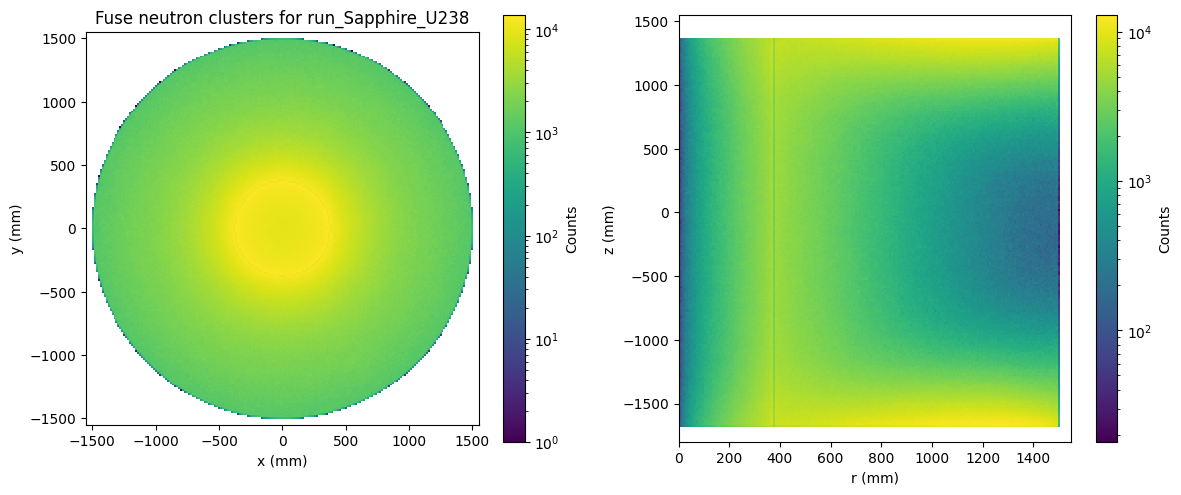

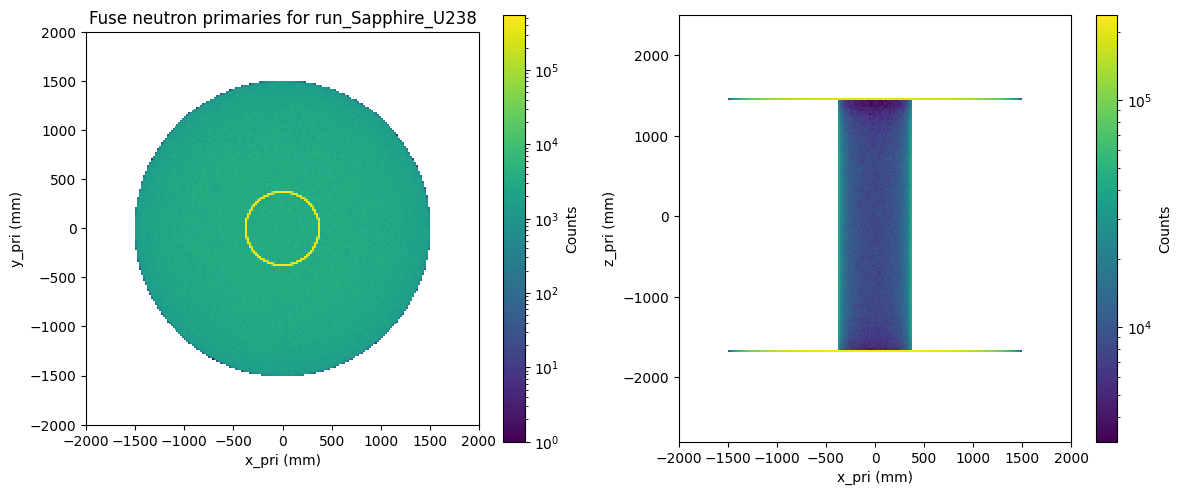

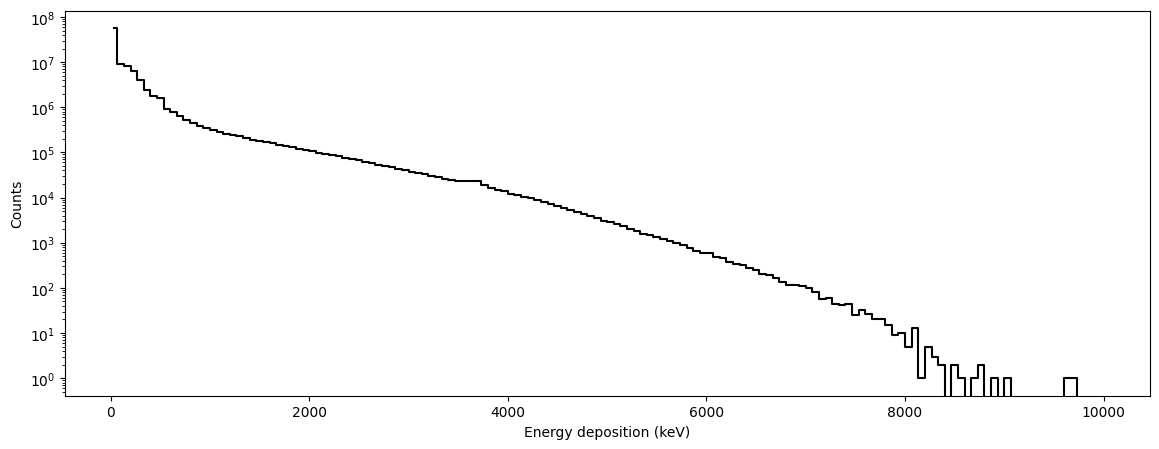

Load run_Teflon_Th232


100%|██████████| 72/72 [02:10<00:00,  1.82s/it]


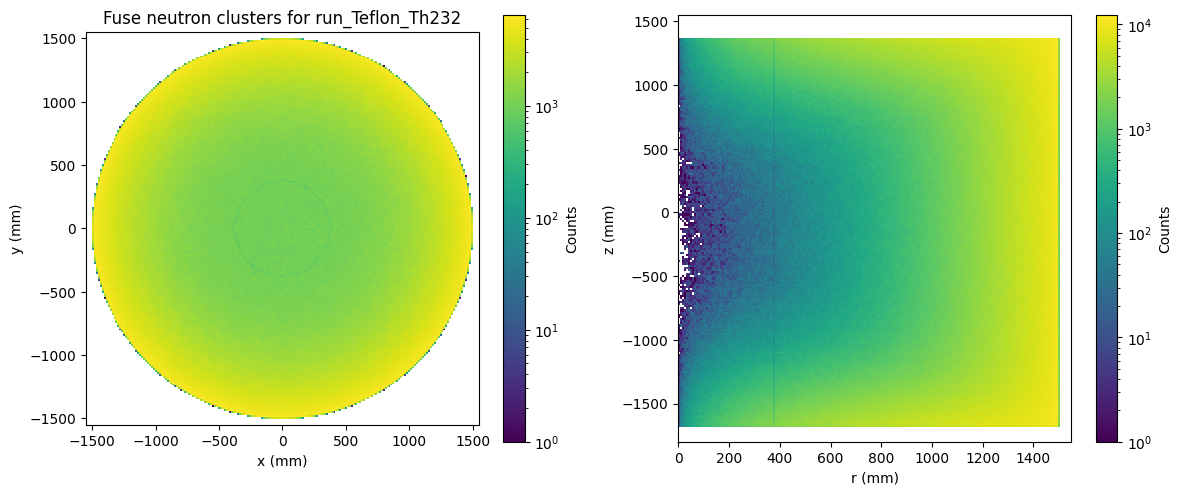

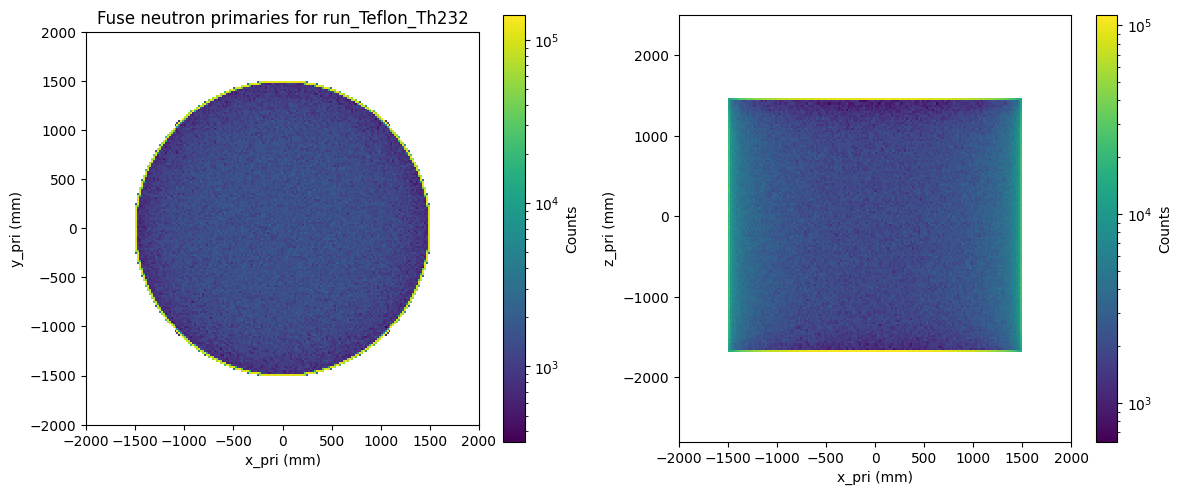

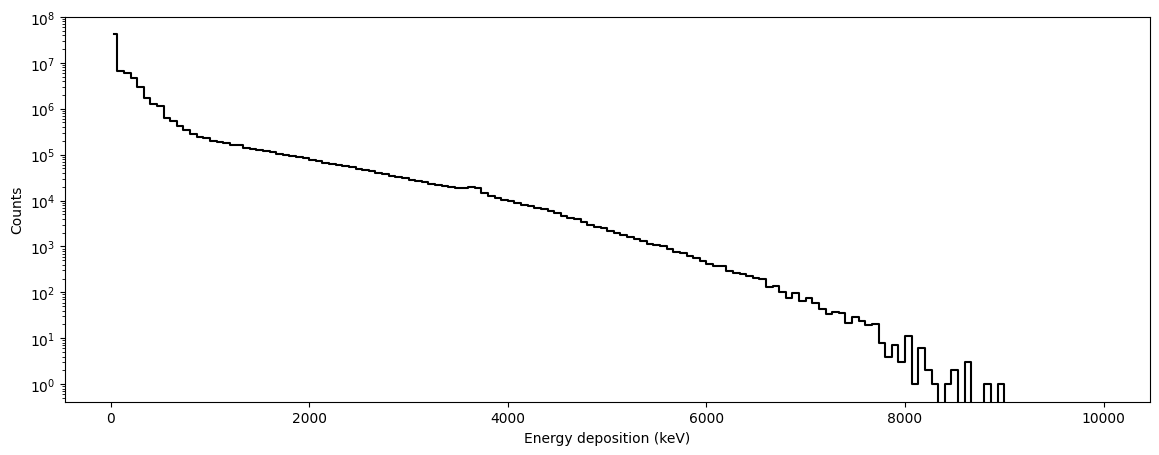

Load run_Cryostat_Th232


100%|██████████| 37/37 [01:06<00:00,  1.79s/it]


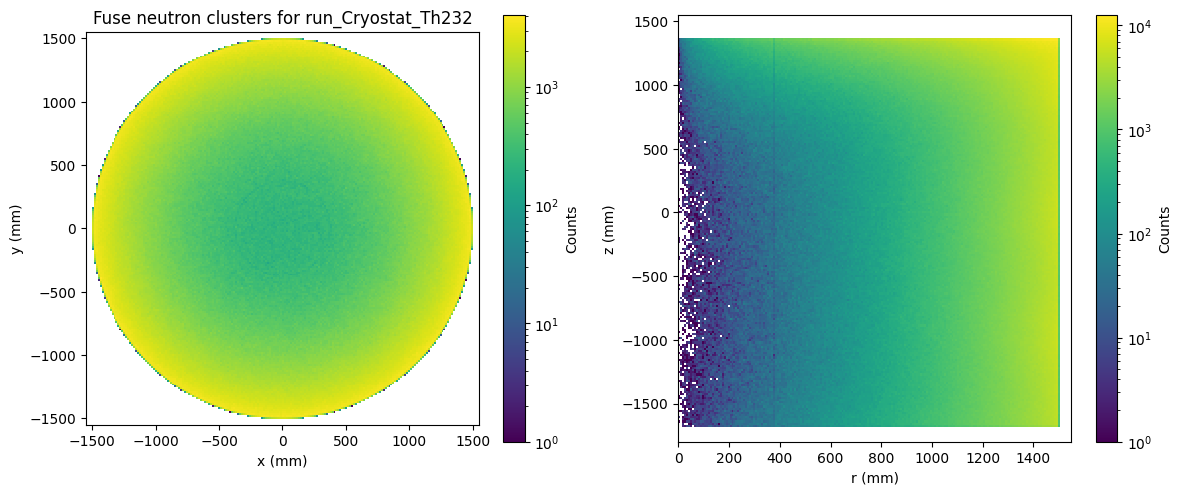

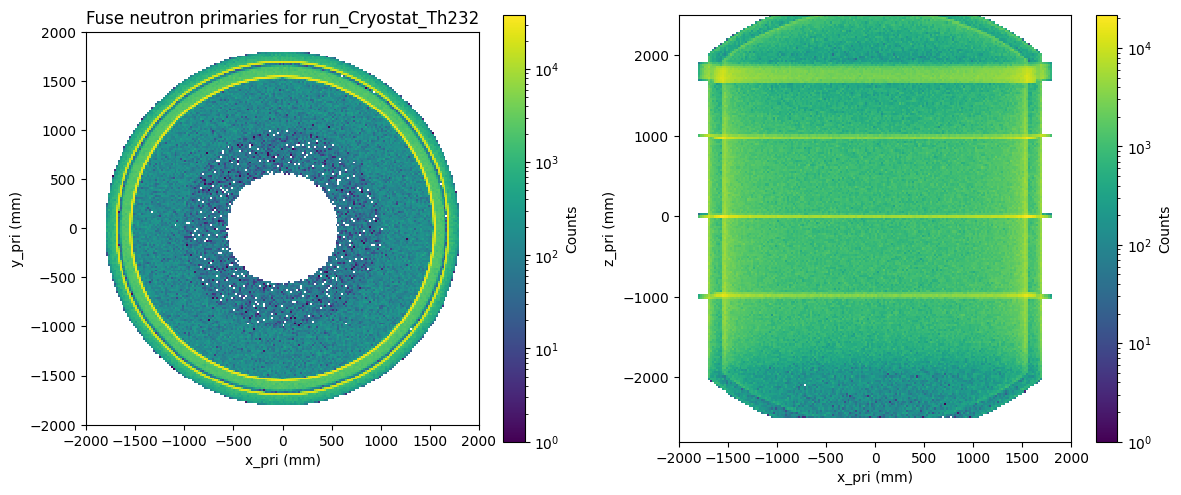

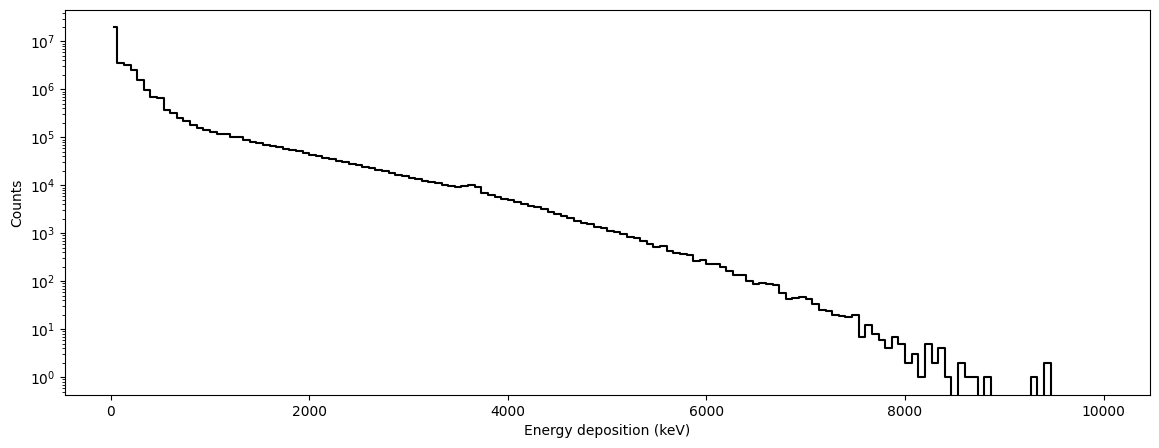

Load run_Teflon_U238


100%|██████████| 72/72 [02:14<00:00,  1.87s/it]


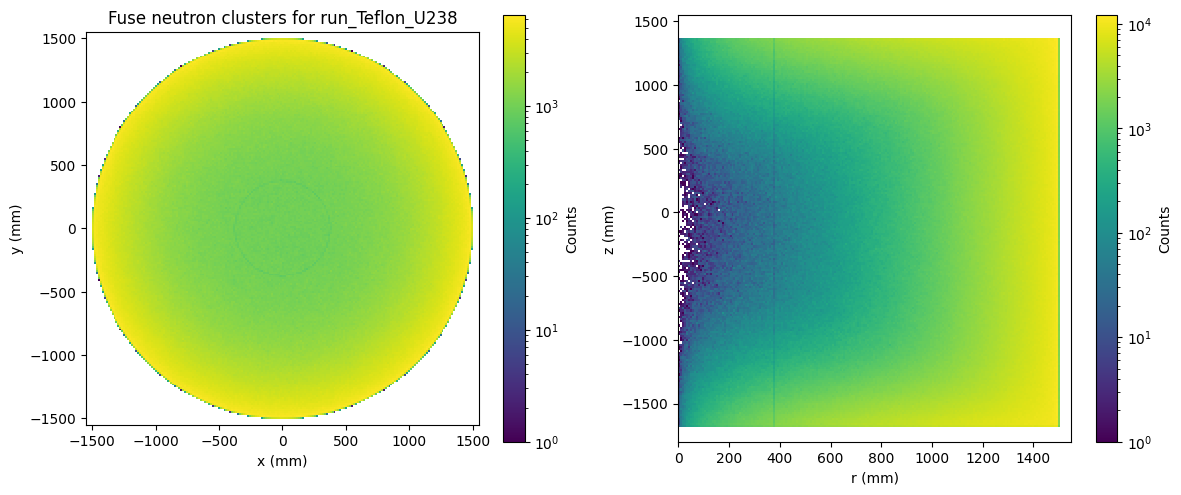

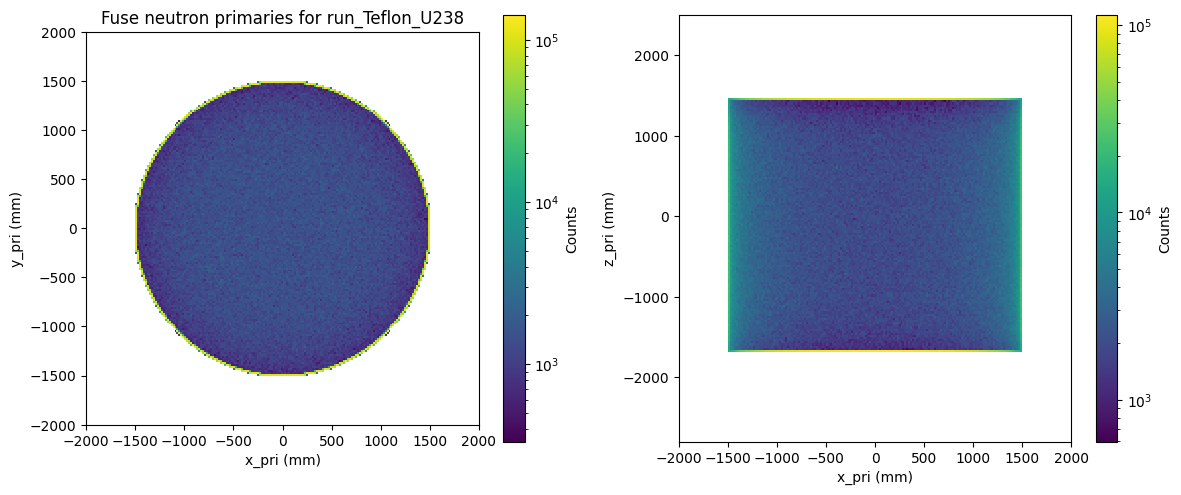

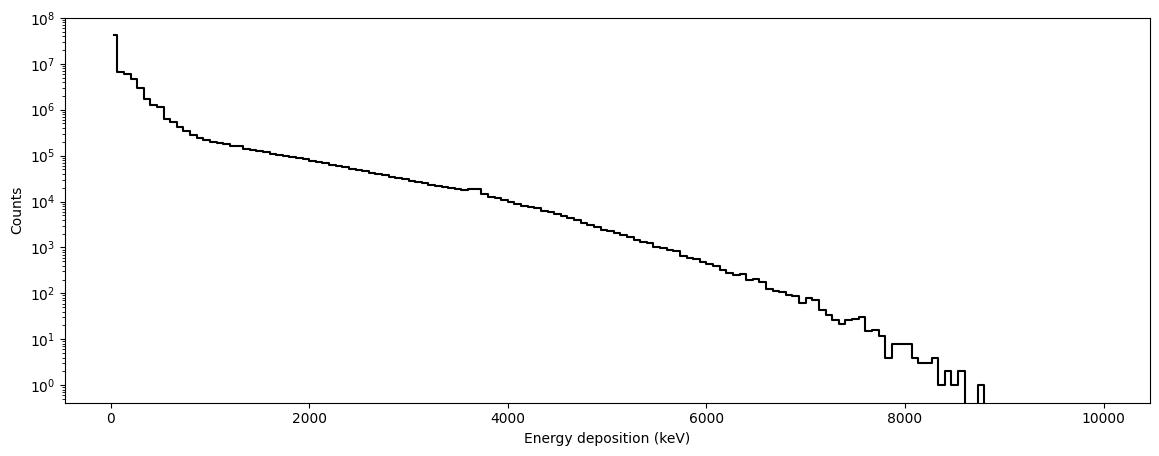

Load run_PMT_U238


100%|██████████| 193/193 [05:45<00:00,  1.79s/it]


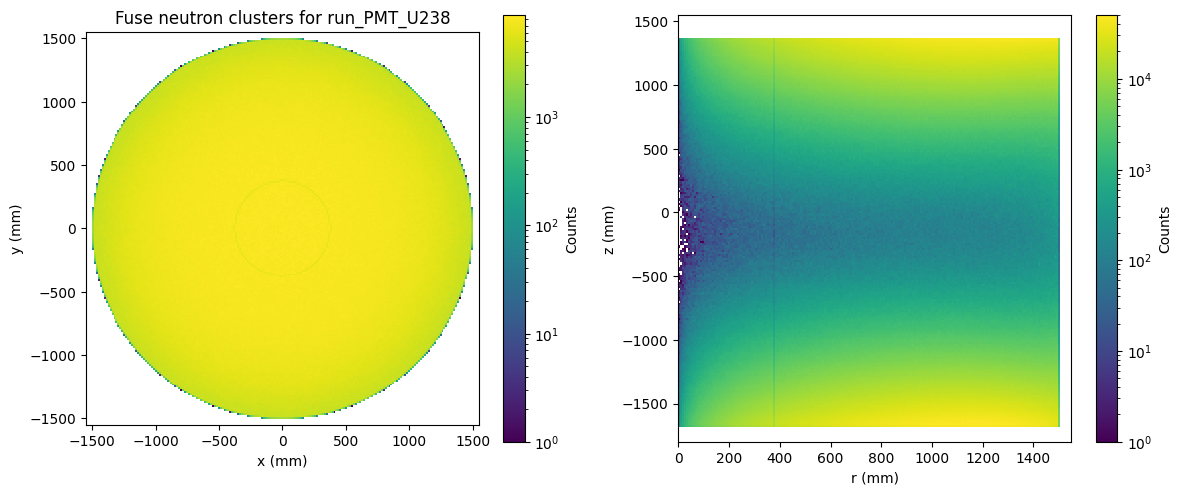

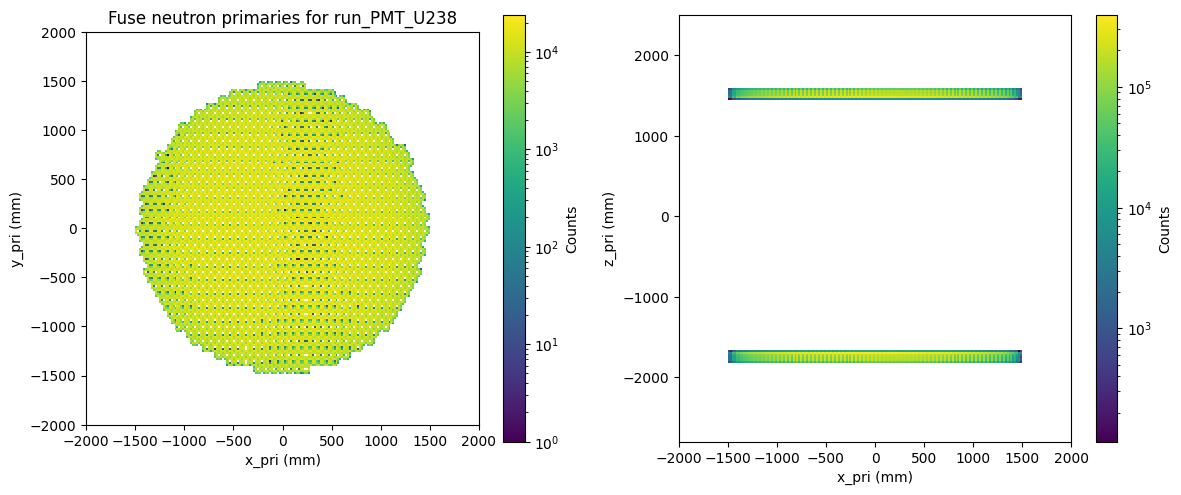

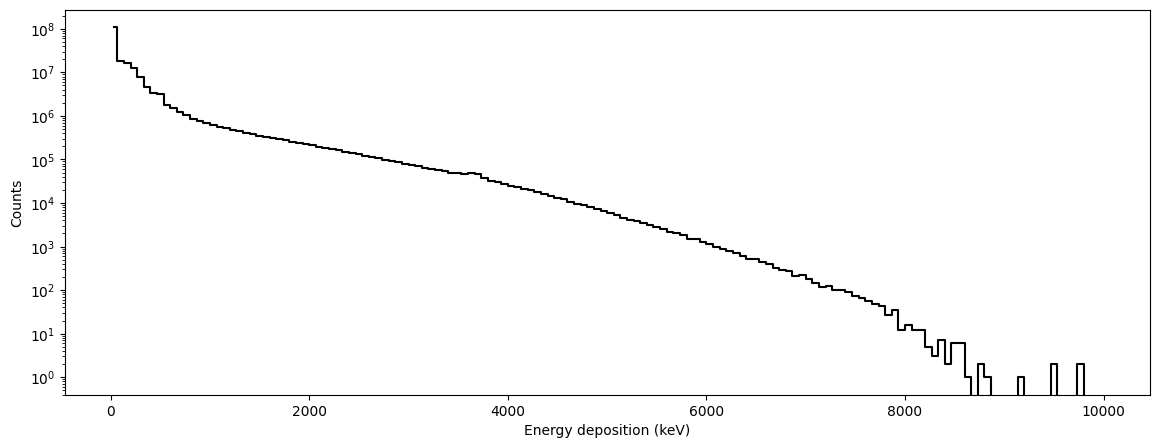

Load run_PMT_Th232


100%|██████████| 66/66 [01:51<00:00,  1.68s/it]


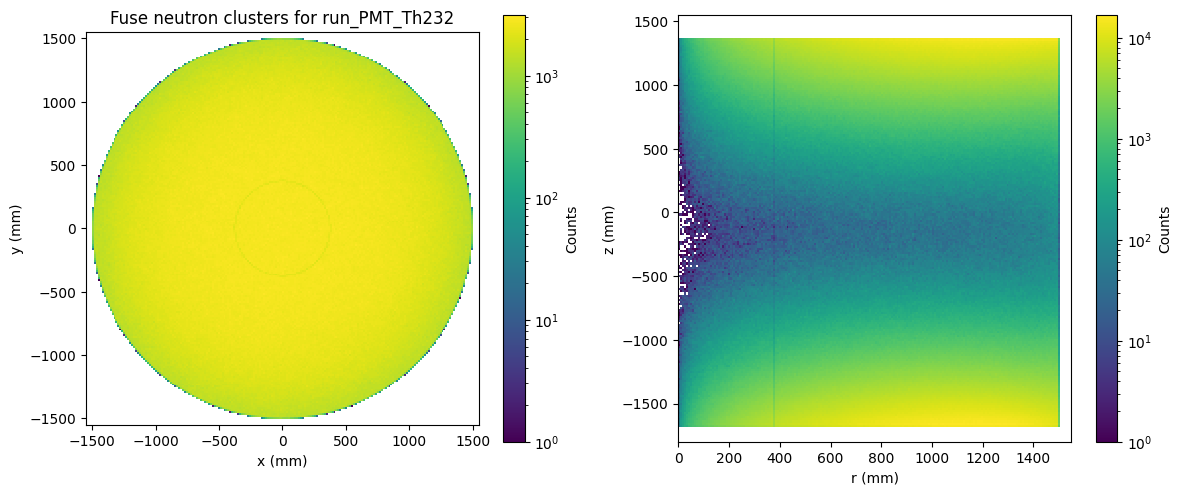

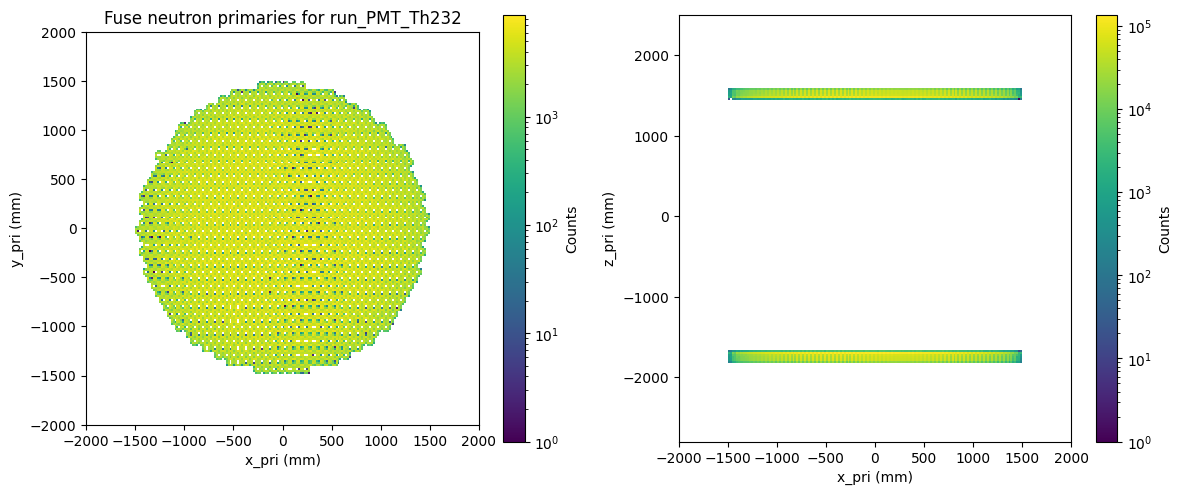

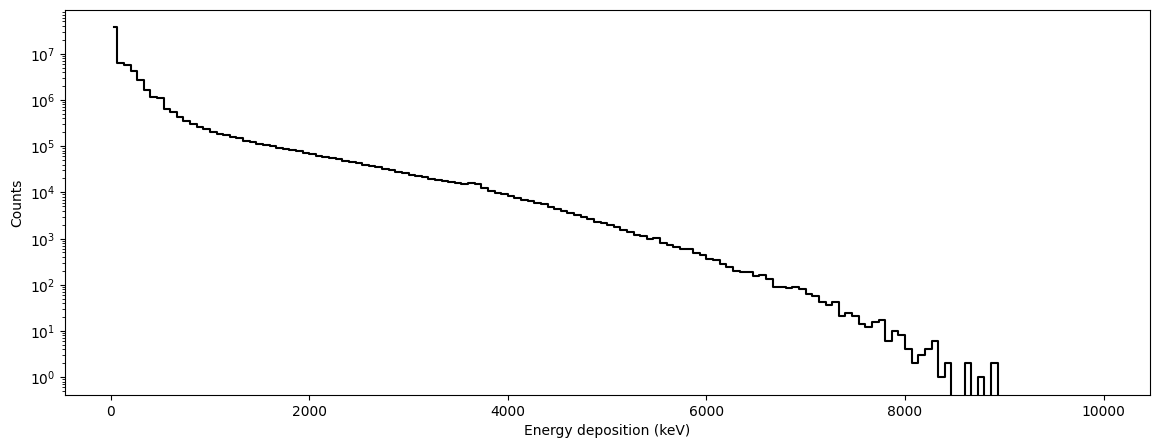

Load run_Sapphire_Th232


100%|██████████| 96/96 [02:56<00:00,  1.84s/it]


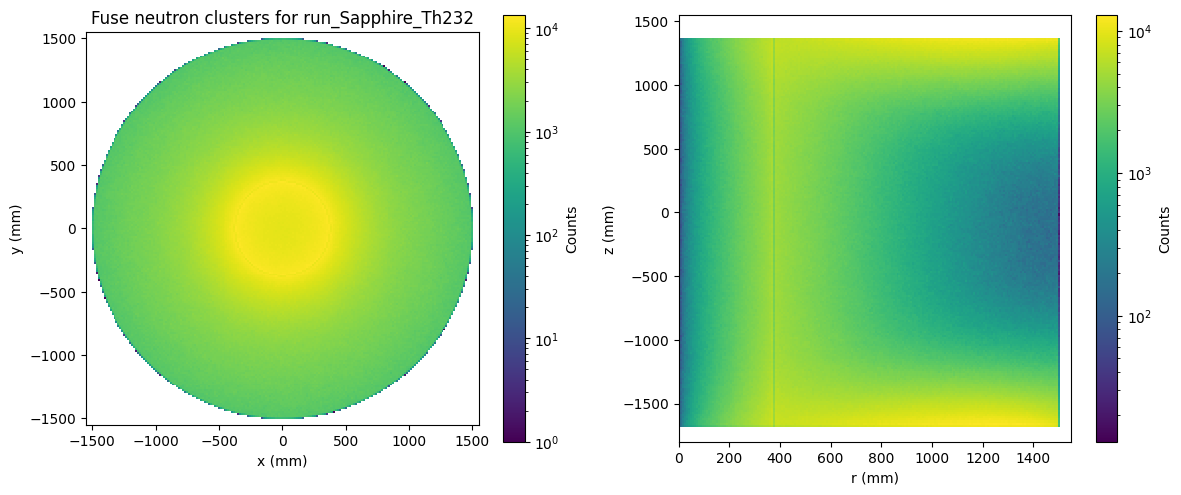

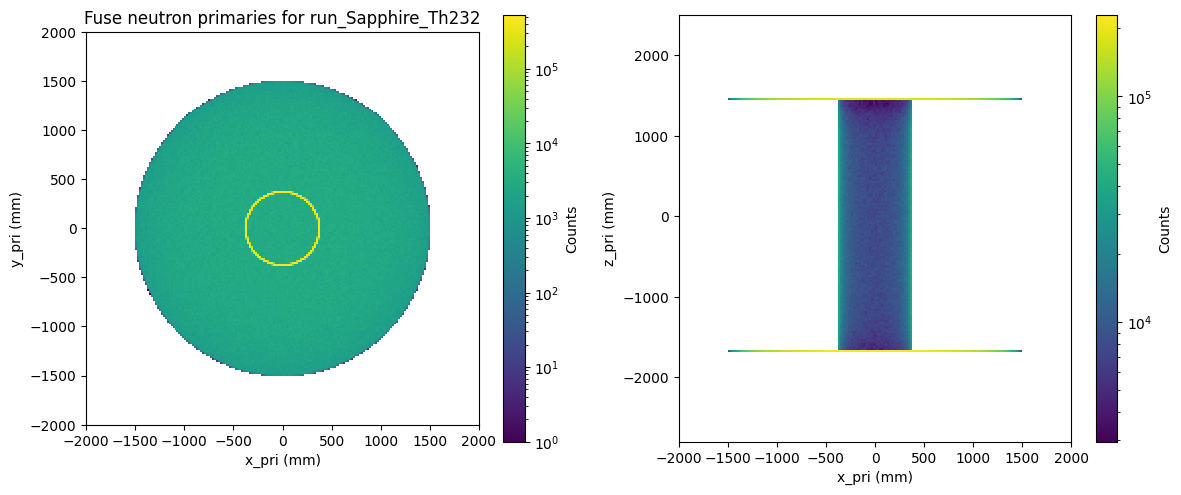

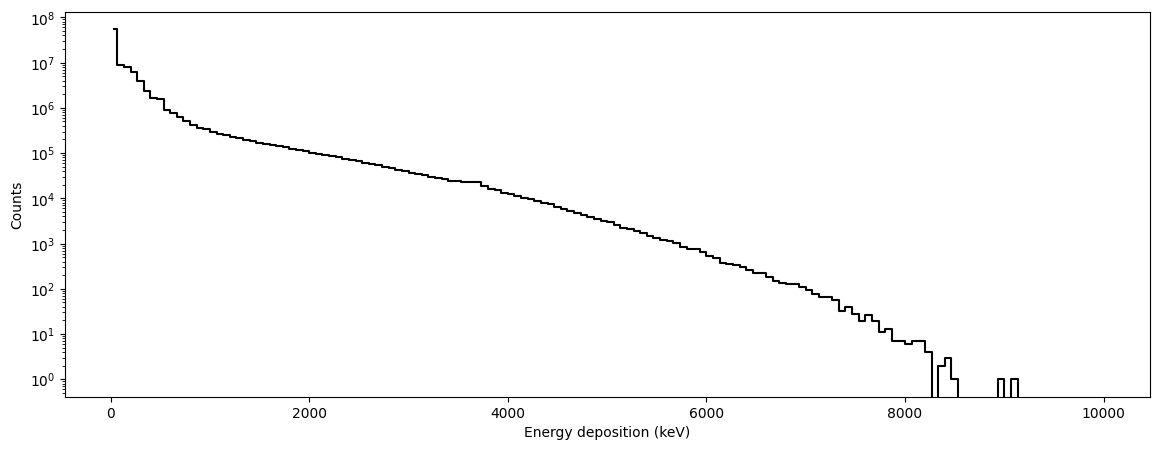

Load run_Copper_Th232


100%|██████████| 75/75 [02:22<00:00,  1.90s/it]


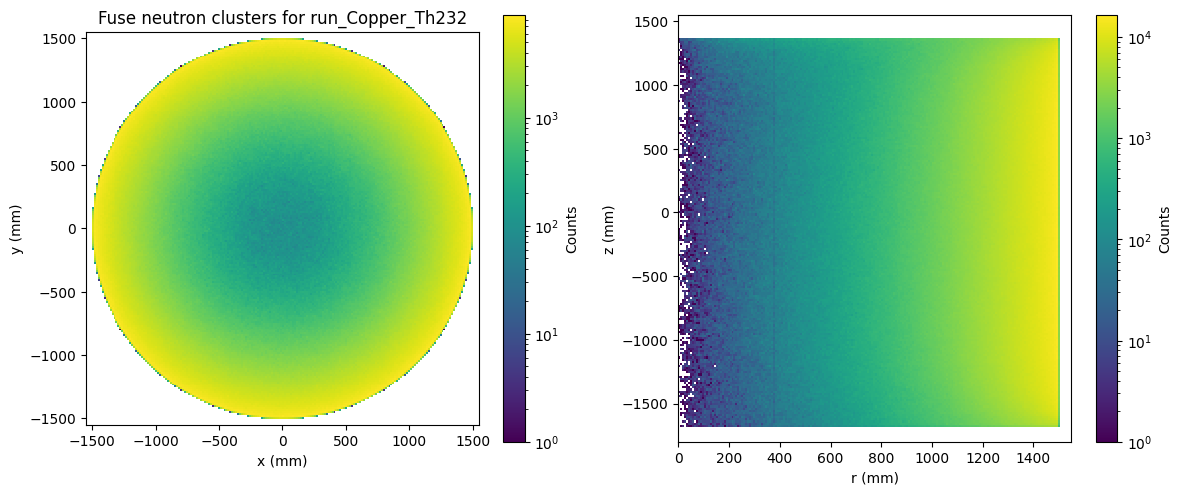

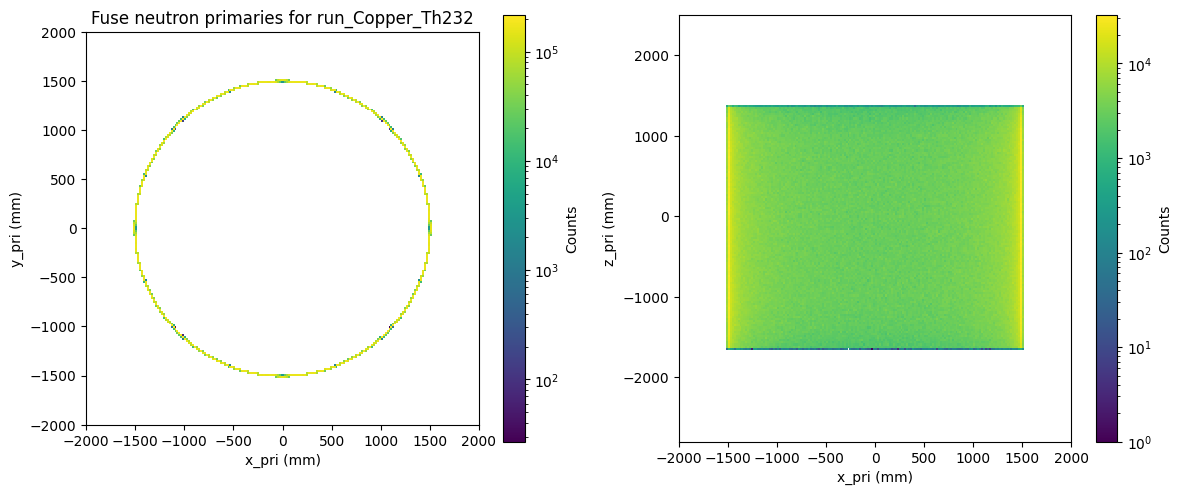

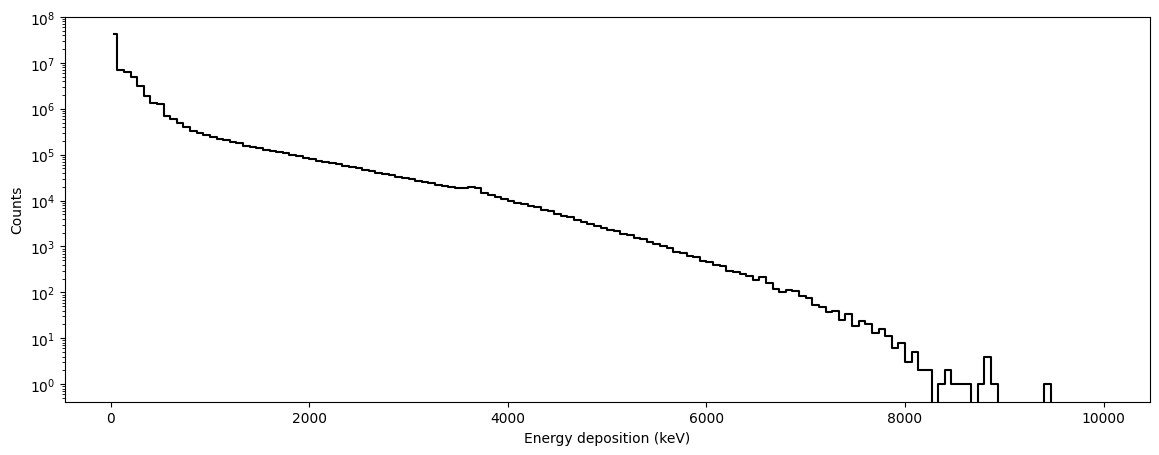

Load run_Copper_U238


100%|██████████| 75/75 [02:14<00:00,  1.80s/it]


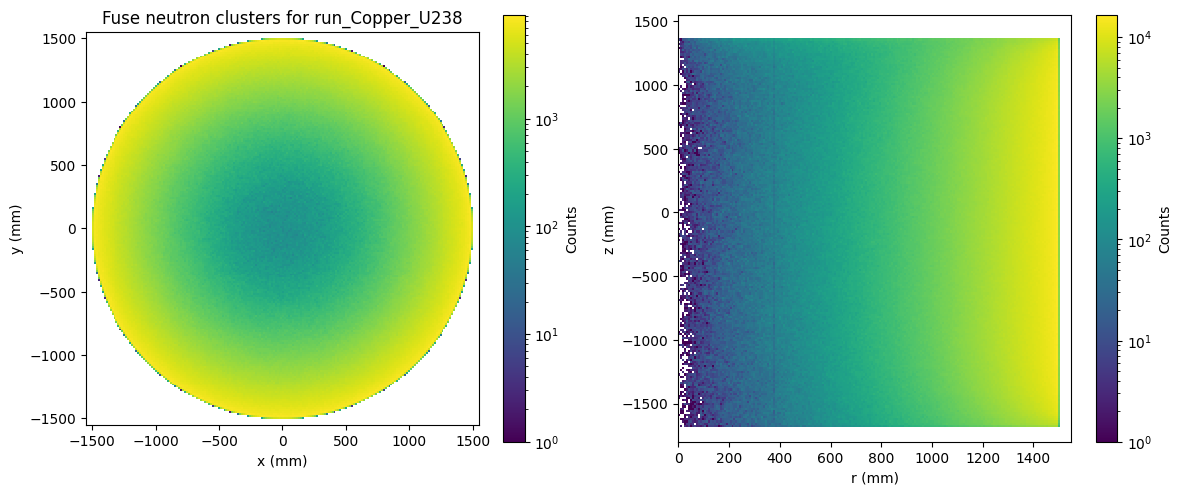

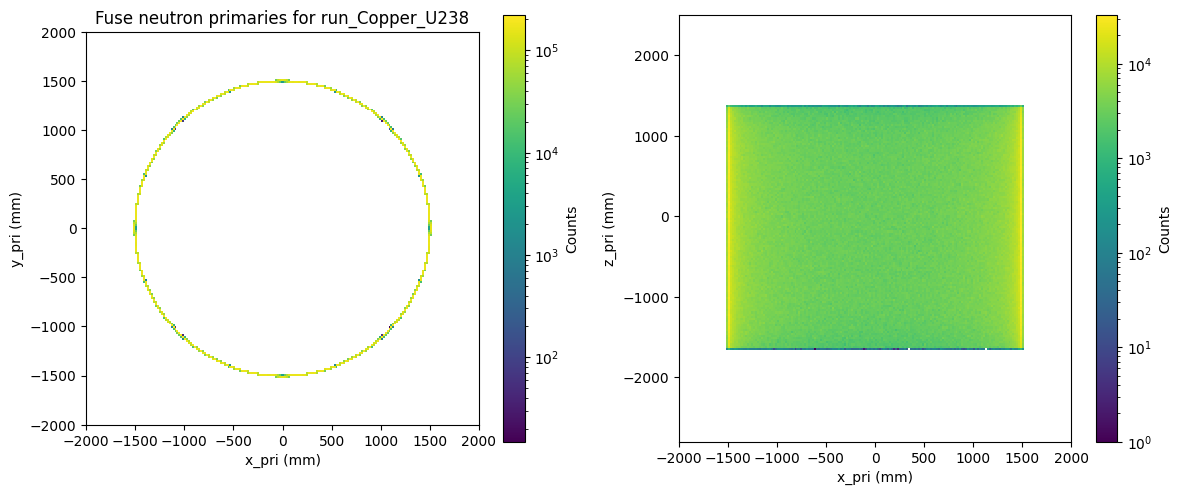

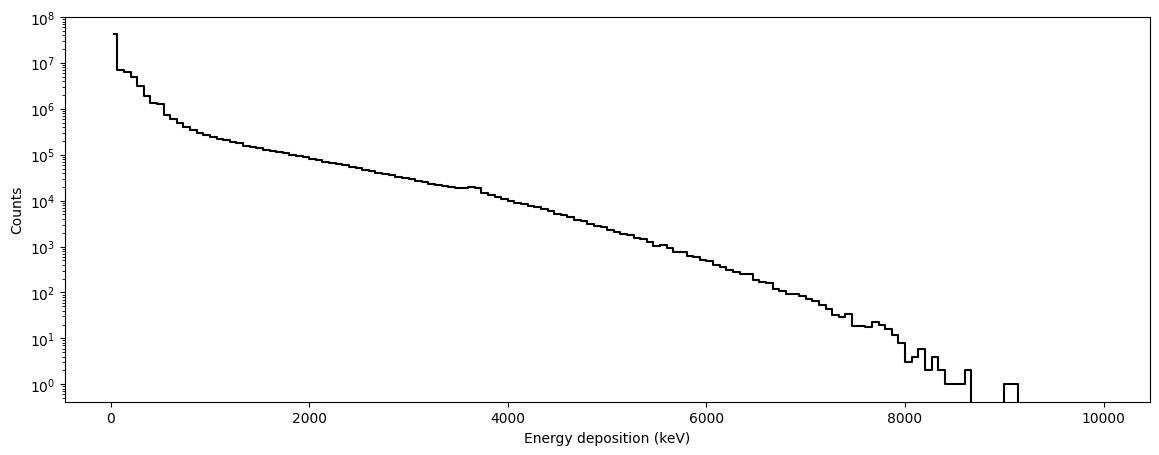

Load run_Cryostat_U238


100%|██████████| 94/94 [03:18<00:00,  2.12s/it]


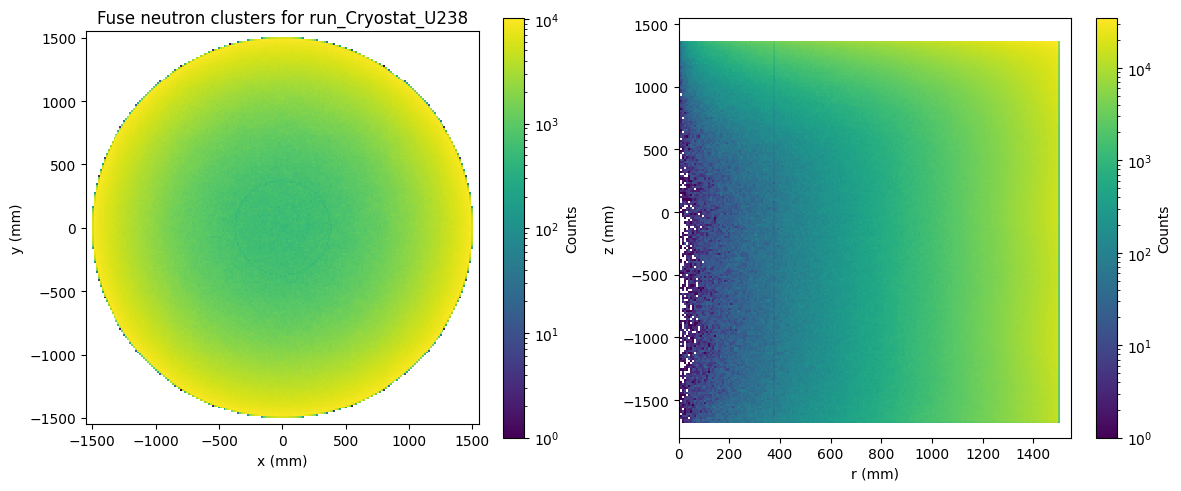

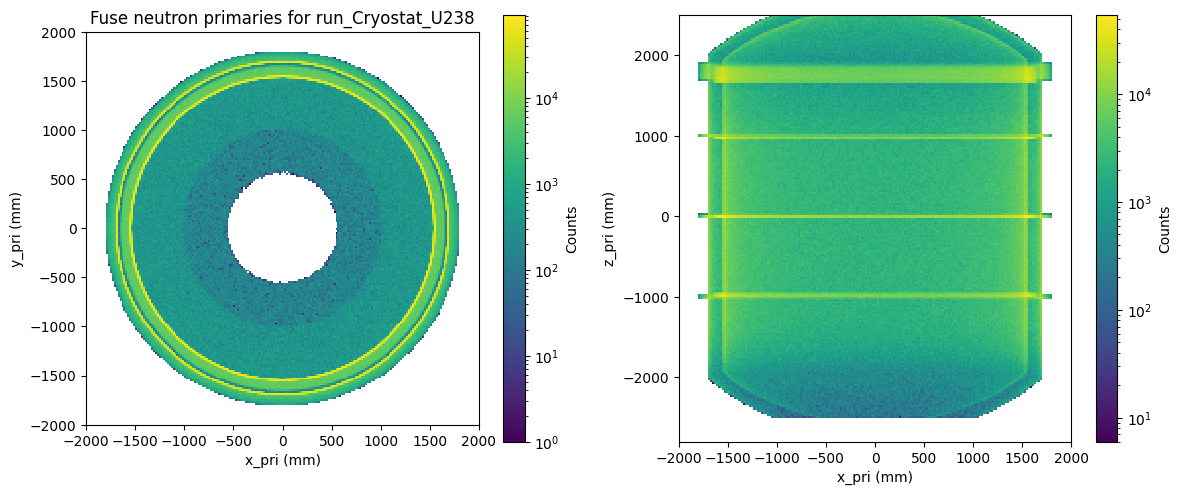

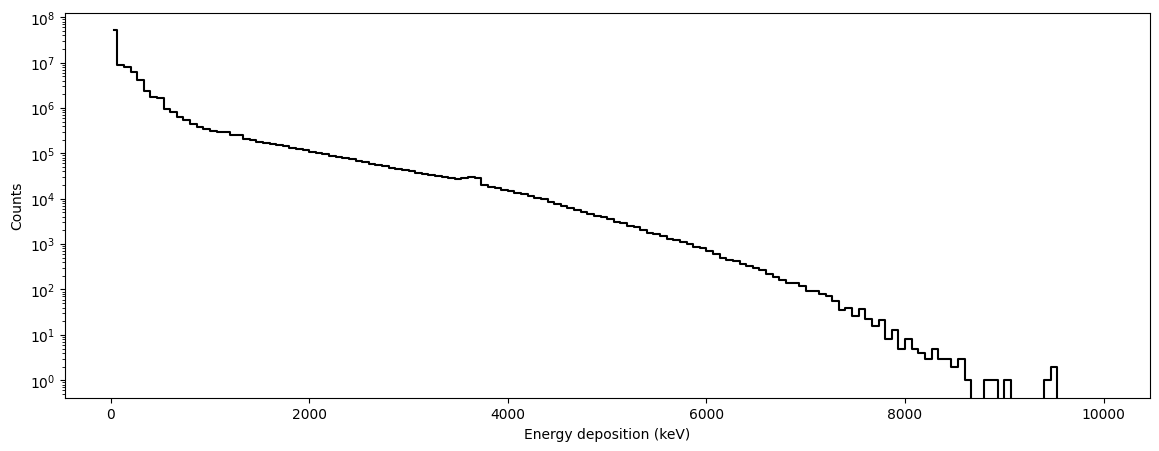

In [7]:
fv_x = 500  # mm
fv_z = (-800, 800)  # mm

for macro, df in dds.items():
    print(f"Load {macro}")
    # Load data in chunks and add to histos
    h_xy = bh.Histogram(bh.axis.Regular(200, -1550, 1550), bh.axis.Regular(200, -1550, 1550))
    h_rz = bh.Histogram(bh.axis.Regular(200, 0, 1550), bh.axis.Regular(200, -1800, 1550))
    h_xy_pri = bh.Histogram(bh.axis.Regular(200, -2000, 2000), bh.axis.Regular(200, -2000, 2000))
    h_xz_pri = bh.Histogram(bh.axis.Regular(200, -2000, 2000), bh.axis.Regular(200, -2800, 2500))
    h_e = bh.Histogram(bh.axis.Regular(150, 0, 10000))

    for chunk in tqdm.tqdm(df.to_delayed()):
        _data = chunk[["x", "y", "z", "ed", "x_pri", "y_pri", "z_pri"]].compute()
        
        h_xy.fill(_data["x"], _data["y"])
        h_rz.fill(np.sqrt(_data["x"]**2 + _data["y"]**2), _data["z"])
        h_xy_pri.fill(_data["x_pri"], _data["y_pri"])
        h_xz_pri.fill(_data["x_pri"], _data["z_pri"])
        h_e.fill(_data["ed"])

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.pcolormesh(*h_xy.axes.edges.T, h_xy.values().T, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Fuse neutron clusters for {macro}")
    ax1.set_xlabel("x (mm)")
    ax1.set_ylabel("y (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.pcolormesh(*h_rz.axes.edges.T, h_rz.values().T, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {key}")
    ax2.set_xlabel("r (mm)")
    ax2.set_ylabel("z (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    # make a box for the fiducial volume
    #ax1.add_patch(plt.Circle((0, 0), fv_x, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))
    #ax2.add_patch(plt.Rectangle((-fv_x, fv_z[0]), 2*fv_x, 2*fv_z[1], color='red', fill=False, linestyle='--', linewidth=2))

    fig.colorbar(hxy, label="Counts")
    fig.colorbar(hyz, label="Counts")
    fig.tight_layout()

    plt.savefig(data_folder+"/fuse_"+macro+"_xy_rz_hist2d.png", dpi=300, bbox_inches='tight')
    plt.show()


    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    hxy = ax1.pcolormesh(*h_xy_pri.axes.edges.T, h_xy_pri.values().T, norm=matplotlib.colors.LogNorm())
    ax1.set_title(f"Fuse neutron primaries for {macro}")
    ax1.set_xlabel("x_pri (mm)")
    ax1.set_ylabel("y_pri (mm)")
    ax1.set_aspect('equal', adjustable='box')

    hyz = ax2.pcolormesh(*h_xz_pri.axes.edges.T, h_xz_pri.values().T, norm=matplotlib.colors.LogNorm())
    #ax2.set_title(f"Fuse Cluster for {macro}")
    ax2.set_xlabel("x_pri (mm)")
    ax2.set_ylabel("z_pri (mm)")
    #ax2.set_aspect('equal', adjustable='box')

    fig.colorbar(hxy, label="Counts")
    fig.colorbar(hyz, label="Counts")
    fig.tight_layout()

    plt.savefig(data_folder+"/fuse_"+macro+"_xy_xz_pri_hist2d.png", dpi=300, bbox_inches='tight')
    plt.show()


    fig = plt.figure(figsize=(14,5))
    #plt.hist(, bins=100, histtype='step', label='All clusters')
    plt.step(h_e.axes[0].centers, h_e.values(), where='mid', label='All clusters', color='black')

    #data_fv = fuse_data[fuse_data["z"].between(*fv_z) & (fuse_data["x"]**2 + fuse_data["y"]**2 <= fv_x**2)]["ed"]
    #plt.hist(data_fv, bins=100, histtype='step', label='FV clusters', color='red')

    #plt.legend()

    plt.xlabel("Energy deposition (keV)")
    plt.ylabel("Counts")
    plt.yscale("log")

    plt.savefig(data_folder+"/fuse_"+macro+"_ed_hist.png", dpi=300, bbox_inches='tight')
    plt.show()

## Volume and mass for each macro

In [5]:
from utils import G4_components

G4_components

{'LXe': {'density': 2.862, 'temperature': 177.05, 'pressure': 1.5},
 'PMT': {'scaling': 2368},
 'Cryostat': {'volume': 1566200.0,
  'density': 7.7,
  'confinement': 'phys_oCryostat phys_iCryostat',
  'scaling': 12059.74},
 'Teflon': {'volume': 130301,
  'density': 2.2,
  'confinement': 'phys_GXeTeflonTub phys_LXeTeflonTub',
  'scaling': 286.6622},
 'Copper': {'volume': 56804.8,
  'density': 8.92,
  'confinement': 'phys_CopperFCTub',
  'scaling': 506.698816},
 'Sapphire': {'volume': 63877.6,
  'density': 3.98,
  'confinement': 'phys_GXeSapphireTub phys_GXeSapphireCap phys_LXeSapphireTub phys_LXeSapphireCap',
  'scaling': 254.232848}}

## Materials and their radiopurity

We first collect all our estimates for the materials used in the TPC and their radiopurity levels. We can use the earlier XENONnT and also DARWIN estimates. However, the DARWIN estimates are quite conservative and much higher than what we achieved in XENONnT.

In addition I found some numbers from CRESST for sapphire directly. We could also use the screening results for the ceramic stem of the XENON PMTs but these are expected to be higher since they are made out of ceramix Al2O3 instead of pure sapphire (Al2O3 single crystal).

Further information from XENONnT:
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:ramirez:20171108_xenonnt_radiogenic_nr_bkg_simulations
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt_sr0:neutron_background_updated_template
* https://xe1t-wiki.lngs.infn.it/doku.php?id=xenon:xenonnt:analysis:sr0_1_nr_background

In [6]:
from utils import neutron_sources, activity

activity

{'PMT': {'Unit': 'mBq/unit',
  'U238': 8.0,
  'Ra226': 0.6,
  'Th232': 0.7,
  'Th228': 0.6,
  'Co60': 0.84},
 'Cryostat': {'U235': 2.395,
  'U238': 12.575,
  'Th228': 1.05,
  'Th232': 1.46,
  'Ra226': 2.9000000000000004},
 'Teflon': {'Material': 'PTFE',
  'Unit': 'mBq/kg',
  'U235': 0.07,
  'U238': 0.13,
  'Th228': 0.06,
  'Th232': 0.05,
  'Ra226': 0.14},
 'Copper': {'Unit': 'mBq/kg',
  'U238': 1.0,
  'Ra226': 0.035,
  'Th232': 0.033,
  'Th228': 0.026,
  'Co60': 0.019},
 'Sapphire': {'Material': 'Al2O3',
  'Unit': 'mBq/unit',
  'U235': 0.28,
  'U238': 1.37,
  'Th228': 0.5,
  'Th232': 0.17,
  'Ra226': 0.26}}

## Calculation of the neutron production rates - neutron yields

The method to derive the neutron production rates for each material is based on the SOURCES-4A code, which takes takes into account (α,n) and spontaneous fission reactions. This is the same method as used in XENONnT such that I quote here their relevant numbers.

As quoted by the developers, SOURCES-4A has a systematic uncertainty of 17 %, much higher than the statistical uncertainty (107 neutrons generated from each component). This means that in the following values are quoted without error, assuming that the uncertainty of the final results is also of 17 %.

In [7]:
from utils import nyield, get_neutron_yield
from utils import G4_TPC

G4_TPC["mass"]

61641.68111533562

In [91]:
# Define a fiducial volume with fixed mass by giving a certain radius and adjusting the z boundaries
fv_radius = 1384 # mm
fv_mass = 48.0e3 # kg

fv_volume_cm3 = fv_mass * 1000 / G4_components["LXe"]["density"] # cm3
fv_height_mm = fv_volume_cm3 / (np.pi * (fv_radius/10)**2) * 10 # mm
fv_z = [G4_TPC["center_point"][2] - fv_height_mm/2, G4_TPC["center_point"][2] + fv_height_mm/2]

if fv_z[0] < G4_TPC["bottom"] or fv_z[1] > G4_TPC["top"]:
    print("Warning: Fiducial volume z boundaries exceed TPC dimensions!")

print(f"TPC bottom: {G4_TPC['bottom']} mm, top: {G4_TPC['top']} mm, radius: {G4_TPC['radius']} mm")
print(f"TPC height: {G4_TPC['top'] - G4_TPC['bottom']} mm, diameter: {2*G4_TPC['radius']} mm")
print("")

print(f"TPC center z position: {G4_TPC['center_point'][2]} mm")
print(f"Fiducial volume height for {fv_mass} kg at radius {fv_radius} mm: {fv_height_mm:.2f} mm")
print(f"Fiducial volume z boundaries for {fv_mass} kg at radius {fv_radius} mm: [{fv_z[0]:.2f}, {fv_z[1]:.2f}] mm")

TPC bottom: -1682 mm, top: 1365 mm, radius: 1500 mm
TPC height: 3047 mm, diameter: 3000 mm

TPC center z position: -158.5 mm
Fiducial volume height for 48000.0 kg at radius 1384 mm: 2787.08 mm
Fiducial volume z boundaries for 48000.0 kg at radius 1384 mm: [-1552.04, 1235.04] mm


In [92]:
def select_events_in_energy_range(df, energy_range=(4, 50)):
    # energy ROI cut
    # NR: (4, 50) keV -> ER: (1, 12) keV
    return df.query(f"ed >= {energy_range[0]} and ed <= {energy_range[1]}")

# and occur inside the fiducial volume and within the energy ROI
def select_events_in_roi(df, fv_z, fv_radius, energy_range=(4, 50)):
    events_roi = df.query(f"ed >= {energy_range[0]} and ed <= {energy_range[1]} and "
                          f"z >= {fv_z[0]} and z <= {fv_z[1]} and "
                          f"x**2 + y**2 <= {fv_radius}**2")
    return events_roi

In [27]:
# Read estimates from file
with open(data_folder+'/neutron_background_estimates.pkl', 'rb') as f:
    estimates = pickle.load(f)

In [34]:
# Calculate heavy computations only
_dds = dds
#_dds = {key: df for key,df in dds.items() if "Cryostat_U238" in key or "PMT_U238" in key}

estimates = {}
for key, df in tqdm.tqdm(_dds.items()):
    material = key.split("_")[1]
    isotope = key.split("_")[2]

    columns = ["x", "y", "z", "ed", "n_clusters"]

    # We select the events that mimic a WIMP signal with a single elastic scatter in the whole active volume
    df_ss = df[df['n_clusters'] == 1][columns].compute()

    # get number of neutrons per key
    # infer from the unique runids and assume 5000 neutrons per runid
    runids = df["runid"].unique().compute()
    events_per_runid = 5000
    n_neutrons = len(runids) * events_per_runid

    _estimates = {isotope: {
        "updated_at": str(pd.Timestamp.now()),
        "df_ss": df_ss,
        "runids": runids,
        "events_per_runid": events_per_runid,
        "n_neutrons": n_neutrons,
    }}

    if material not in estimates:
        estimates[material] = {}
    estimates[material].update(_estimates)

# Store estimates to file
with open(data_folder+'/neutron_background_estimates.pkl', 'wb') as f:
    pickle.dump(estimates, f)

100%|██████████| 10/10 [40:37<00:00, 243.73s/it]


In [93]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        # Read single scatter events dataframe
        df_ss = iso_data["df_ss"]

        df_ss_energy = select_events_in_energy_range(df_ss, energy_range=(4, 50))
        df_ss_roi = select_events_in_roi(df_ss, fv_z, fv_radius, energy_range=(4, 50))

        # get number of neutrons per key
        # infer from the unique runids and assume 5000 neutrons per runid
        n_neutrons = iso_data["n_neutrons"]

        # get number of total decays
        n_decays = n_neutrons / get_neutron_yield(material, isotope) #nyield[map_material_name(material)][isotope]

        # get estimate of neutron per year
        # activity in mBq/unit or mBq/kg
        # scaling in kg
        simulated_exposure = n_decays / (activity[material][isotope]*1e-3*G4_components[material]["scaling"]) /(60*60*24*365.25) # in years

        # get number of single scatter events total and in ROI
        n_ss_events = len(df_ss)
        #n_ss_energy_events = len(df_ss_energy)
        n_ss_roi_events = len(df_ss_roi)

        # Store histograms
        r_max = 1600
        h_xy_ss = bh.Histogram(bh.axis.Regular(200, -r_max, r_max), bh.axis.Regular(200, -r_max, r_max))
        h_xy_ss_energy = bh.Histogram(bh.axis.Regular(200, -r_max, r_max), bh.axis.Regular(200, -r_max, r_max))
        h_xy_ss_roi = bh.Histogram(bh.axis.Regular(200, -r_max, r_max), bh.axis.Regular(200, -r_max, r_max))
        h_rz_ss = bh.Histogram(bh.axis.Regular(200, 0, r_max), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss_energy = bh.Histogram(bh.axis.Regular(200, 0, r_max), bh.axis.Regular(200, -1800, 1500))
        h_rz_ss_roi = bh.Histogram(bh.axis.Regular(200, 0, r_max), bh.axis.Regular(200, -1800, 1500))
        h_rrz_ss = bh.Histogram(bh.axis.Regular(200, 0, r_max**2), bh.axis.Regular(200, -1800, 1500))
        h_rrz_ss_energy = bh.Histogram(bh.axis.Regular(200, 0, r_max**2), bh.axis.Regular(200, -1800, 1500))
        h_rrz_ss_roi = bh.Histogram(bh.axis.Regular(200, 0, r_max**2), bh.axis.Regular(200, -1800, 1500))

        h_xy_ss.fill(df_ss["x"], df_ss["y"])
        h_rz_ss.fill(np.sqrt(df_ss["x"]**2 + df_ss["y"]**2), df_ss["z"])
        h_rrz_ss.fill(df_ss["x"]**2 + df_ss["y"]**2, df_ss["z"])

        h_xy_ss_energy.fill(df_ss_energy["x"], df_ss_energy["y"])
        h_rz_ss_energy.fill(np.sqrt(df_ss_energy["x"]**2 + df_ss_energy["y"]**2), df_ss_energy["z"])
        h_rrz_ss_energy.fill(df_ss_energy["x"]**2 + df_ss_energy["y"]**2, df_ss_energy["z"])

        h_xy_ss_roi.fill(df_ss_roi["x"], df_ss_roi["y"])
        h_rz_ss_roi.fill(np.sqrt(df_ss_roi["x"]**2 + df_ss_roi["y"]**2), df_ss_roi["z"])
        h_rrz_ss_roi.fill(df_ss_roi["x"]**2 + df_ss_roi["y"]**2, df_ss_roi["z"])

        _isotope = {
            "n_decays": n_decays,
            "simulated_exposure_years": simulated_exposure,
            "fv_z": fv_z,
            "fv_radius": fv_radius,
            "df_ss_energy": df_ss_energy,
            "n_ss_events": n_ss_events,
            "n_ss_roi_events": n_ss_roi_events,
            "h_xy_ss": h_xy_ss,
            "h_xy_ss_energy": h_xy_ss_energy,
            "h_xy_ss_roi": h_xy_ss_roi,
            "h_rz_ss": h_rz_ss,
            "h_rz_ss_energy": h_rz_ss_energy,
            "h_rz_ss_roi": h_rz_ss_roi,
            "h_rrz_ss": h_rrz_ss,
            "h_rrz_ss_energy": h_rrz_ss_energy,
            "h_rrz_ss_roi": h_rrz_ss_roi,
        }

        estimates[material][isotope].update(_isotope)

# Store estimates to file
#with open(data_folder+'/neutron_background_estimates.pkl', 'wb') as f:
#    pickle.dump(estimates, f)

In [57]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        print(f"Material: {material}, Isotope: {isotope}, max runid: {max(iso_data['runids'])}")

Material: Sapphire, Isotope: U238, max runid: 737
Material: Sapphire, Isotope: Th232, max runid: 737
Material: Teflon, Isotope: Th232, max runid: 737
Material: Teflon, Isotope: U238, max runid: 737
Material: Cryostat, Isotope: Th232, max runid: 737
Material: Cryostat, Isotope: U238, max runid: 2199
Material: PMT, Isotope: U238, max runid: 2199
Material: PMT, Isotope: Th232, max runid: 737
Material: Copper, Isotope: Th232, max runid: 737
Material: Copper, Isotope: U238, max runid: 737


In [59]:
862+(1000//8)

987

In [94]:
total_event_year = 0.0
total_event_rate = 0.0

total_event_year_sapphire = 0.0
total_event_rate_sapphire = 0.0

for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        events_year = iso_data['n_ss_roi_events']/iso_data['simulated_exposure_years']
        event_rate = events_year/(fv_mass/1e3)
        if material == "Sapphire":
            total_event_year_sapphire += events_year
            total_event_rate_sapphire += event_rate
        else:
            total_event_year += events_year
            total_event_rate += event_rate

        print(f"Material: {material}, Isotope: {isotope}")
        print(f"  Number of neutrons simulated: {iso_data['n_neutrons']}")
        print(f"  Number of decays simulated: {iso_data['n_decays']:.2e}")
        print(f"  Simulated exposure: {iso_data['simulated_exposure_years']:.2f} years")
        print(f"  Total single scatter events: {iso_data['n_ss_events']}")
        print(f"  -> in fiducial volume and energy ROI: {iso_data['n_ss_roi_events']}")
        print(f"  -> as events [events/year]: {events_year:.5f}")
        print(f"  -> as event rate [events/tonne/year]: {event_rate:.5f}")
        print()

print(f"Nominal neutron background event rate in fiducial volume and energy ROI: {total_event_year:.4f} events/year")
print(f"Nominal neutron background event rate in fiducial volume and energy ROI: {total_event_rate:.4f} events/tonne/year")
print("")
print(f"Sap. neutron background event rate in fiducial volume and energy ROI: {total_event_year+total_event_year_sapphire:.4f} events/year")
print(f"Sap. neutron background event rate in fiducial volume and energy ROI: {total_event_rate+total_event_rate_sapphire:.4f} events/tonne/year")

Material: Sapphire, Isotope: U238
  Number of neutrons simulated: 3445000
  Number of decays simulated: 2.87e+12
  Simulated exposure: 261187.14 years
  Total single scatter events: 103641
  -> in fiducial volume and energy ROI: 1397
  -> as events [events/year]: 0.00535
  -> as event rate [events/tonne/year]: 0.00011

Material: Sapphire, Isotope: Th232
  Number of neutrons simulated: 3445000
  Number of decays simulated: 3.74e+14
  Simulated exposure: 274547091.88 years
  Total single scatter events: 107843
  -> in fiducial volume and energy ROI: 1332
  -> as events [events/year]: 0.00000
  -> as event rate [events/tonne/year]: 0.00000

Material: Teflon, Isotope: Th232
  Number of neutrons simulated: 3675000
  Number of decays simulated: 5.03e+12
  Simulated exposure: 11129869.76 years
  Total single scatter events: 154708
  -> in fiducial volume and energy ROI: 1704
  -> as events [events/year]: 0.00015
  -> as event rate [events/tonne/year]: 0.00000

Material: Teflon, Isotope: U238


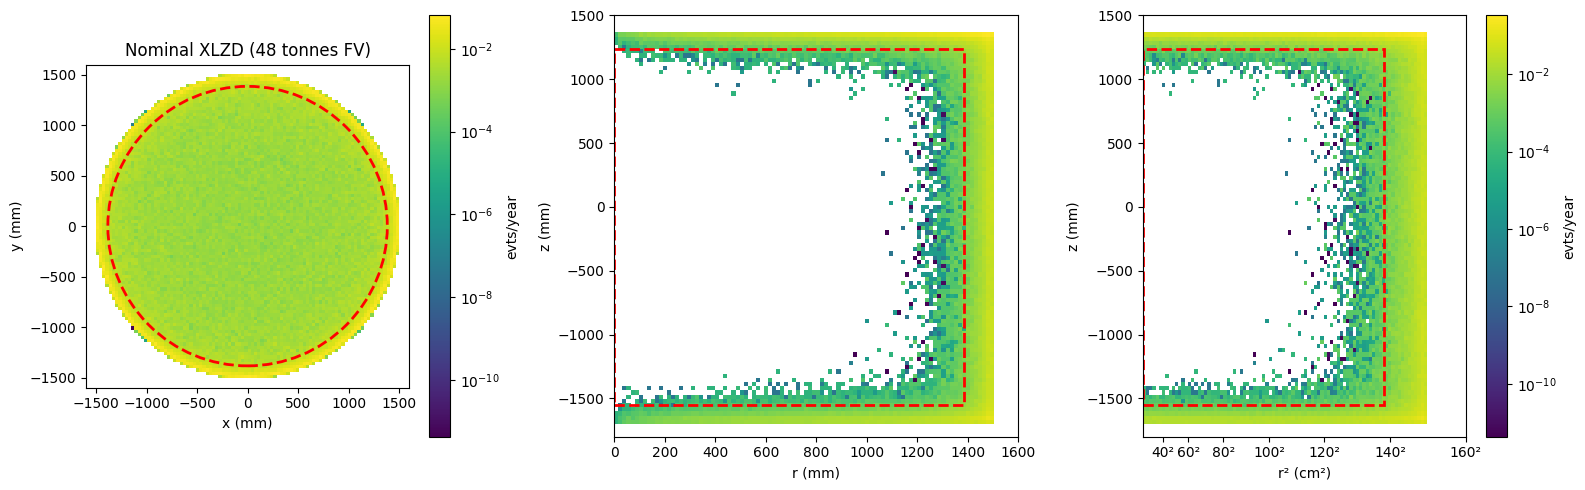

In [95]:
fig, (ax1, ax2, ax3) = plt.subplots(nrows=1, ncols=3, figsize=(16,5))
tag = "_ss_energy"

h_xy_nominal = estimates['Copper']['Th232']["h_xy_ss_energy"].copy()*0.0
h_rz_nominal = estimates['Copper']['Th232']["h_rz_ss_energy"].copy()*0.0
h_rrz_nominal = estimates['Copper']['Th232']["h_rrz_ss_energy"].copy()*0.0
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        if "Sapphire" in material:
            continue  # skip Sapphire as it is not in the nominal background model
        h_xy_nominal += iso_data["h_xy"+tag]/iso_data['simulated_exposure_years'] # per year
        h_rz_nominal += iso_data["h_rz"+tag]/iso_data['simulated_exposure_years'] # per year
        h_rrz_nominal += iso_data["h_rrz"+tag]/iso_data['simulated_exposure_years'] # per year

scale = 2
h_xy_nominal = h_xy_nominal[::bh.rebin(scale), ::bh.rebin(scale)]
h_rz_nominal = h_rz_nominal[::bh.rebin(scale), ::bh.rebin(scale)]
h_rrz_nominal = h_rrz_nominal[::bh.rebin(scale), ::bh.rebin(scale)]

pcm1 = ax1.pcolormesh(*h_xy_nominal.axes.edges.T, h_xy_nominal.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

ax1.set_title(f"Nominal XLZD (48 tonnes FV)")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
ax1.set_aspect('equal', adjustable='box')

pcm2 = ax2.pcolormesh(*h_rz_nominal.axes.edges.T, h_rz_nominal.values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

pcm2 = ax3.pcolormesh(*h_rrz_nominal.axes.edges.T, h_rrz_nominal.values().T, norm=matplotlib.colors.LogNorm())
ax3.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius**2, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

# Use same ticks for r² axis as for r axis
r_ticks = ax2.get_xticks()[2:]
r2_ticks = r_ticks**2
ax3.set_xticks(r2_ticks)
ax3.set_xticklabels([f"{tick/10:.0f}²" for tick in r_ticks])

ax3.set_xlabel("r² (cm²)")
ax3.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/year")
plt.colorbar(pcm2, label="evts/year")
fig.tight_layout()
plt.show()

In [96]:
# Calculate the volume-normalization
v_xy = estimates['Copper']['Th232']["h_xy_ss_energy"].copy().reset()
v_rz = estimates['Copper']['Th232']["h_rz_ss_energy"].copy().reset()

# Calculate volume of each bin in mm^3
bin_areas_xy = np.diff(v_xy.axes[0].edges)[:, None] * np.diff(v_xy.axes[1].edges)[None, :]  # mm^2
bin_volumes_xy = bin_areas_xy * (fv_z[1] - fv_z[0])  # mm^3
bin_areas_rz = np.diff(v_rz.axes[0].edges)[:, None] * np.diff(v_rz.axes[1].edges)[None, :]  # mm^2
bin_volumes_rz = bin_areas_rz * (2 * np.pi * v_rz.axes[0].centers[:, None])  # mm^3

v_xy.view()[:] = bin_volumes_xy*G4_components["LXe"]['density']/1e9 # in tonnes
v_rz.view()[:] = bin_volumes_rz*G4_components["LXe"]['density']/1e9 # in tonnes

In [97]:
# Sum all volumes to check normalization -> should be close to 60 tonnes
_h_r = v_rz[:bh.loc(G4_TPC["radius"]), bh.loc(G4_TPC["bottom"]):bh.loc(G4_TPC["top"]):bh.sum]
print("Total LXe mass in TPC:", np.sum(_h_r.values()), "tonnes")

Total LXe mass in TPC: 61.092015939724405 tonnes


In [115]:
# Integrate over the fiducial volume
h_r_slice = v_rz[:bh.loc(fv_radius), bh.loc(fv_z[0]):bh.loc(fv_z[1]+1):bh.sum]
print("Total LXe mass in FV:", np.sum(h_r_slice.counts()))

Total LXe mass in FV: 48.02444241221447


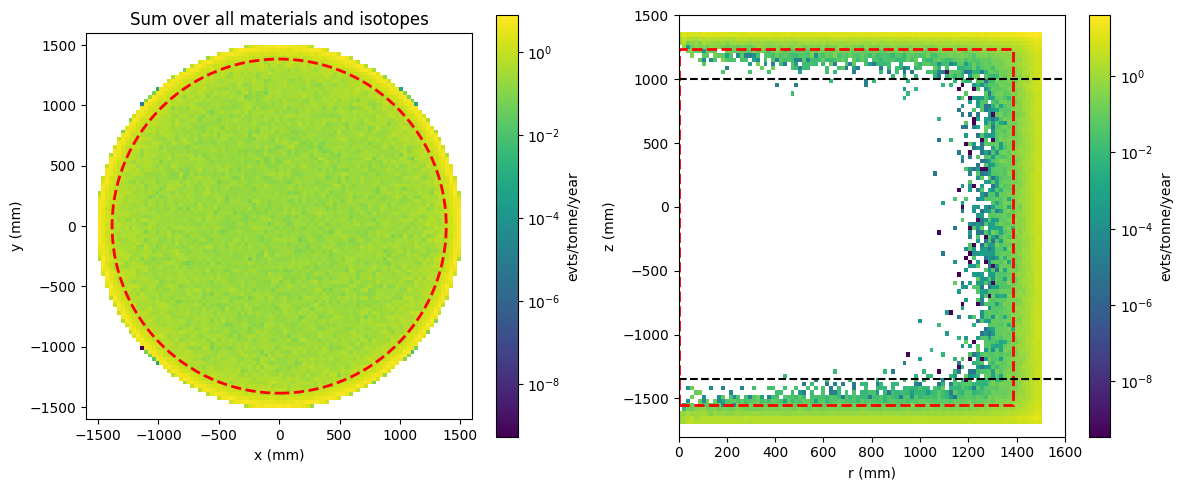

In [98]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
tag = "_ss_energy"

h_xy_nominal = estimates['Copper']['Th232']["h_xy_ss_energy"].copy()*0.0
h_rz_nominal = estimates['Copper']['Th232']["h_rz_ss_energy"].copy()*0.0
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        if "Sapphire" in material:
            continue  # skip Sapphire as it is not in the nominal background model
        h_xy_nominal += iso_data["h_xy"+tag]/iso_data['simulated_exposure_years'] # per year
        h_rz_nominal += iso_data["h_rz"+tag]/iso_data['simulated_exposure_years'] # per year
        #print(material, isotope, iso_data["h_rz"+tag]/iso_data['simulated_exposure_years'])
        #simulated_exposure = iso_data['n_decays'] / (activity[material][isotope]*1e-3*G4_components[material]["scaling"]) /(60*60*24*365.25) # in years
        #h_xy_nominal += iso_data["h_xy"+tag]/simulated_exposure # per year
        #h_rz_nominal += iso_data["h_rz"+tag]/simulated_exposure # per year

scale = 2
h_xy_nominal = h_xy_nominal[::bh.rebin(scale), ::bh.rebin(scale)]
h_rz_nominal = h_rz_nominal[::bh.rebin(scale), ::bh.rebin(scale)]

h_xy_nominal /= v_xy[::bh.rebin(scale), ::bh.rebin(scale)] # per year per tonne
h_rz_nominal /= v_rz[::bh.rebin(scale), ::bh.rebin(scale)] # per year per tonne

pcm1 = ax1.pcolormesh(*h_xy_nominal.axes.edges.T, h_xy_nominal.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

ax1.set_title(f"Sum over all materials and isotopes")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
ax1.set_aspect('equal', adjustable='box')

pcm2 = ax2.pcolormesh(*h_rz_nominal.axes.edges.T, h_rz_nominal.values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.axhline(-1350, color='black', linestyle='--', label='TPC Bottom')
ax2.axhline(1000, color='black', linestyle='--', label='TPC Top')

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/tonne/year")
plt.colorbar(pcm2, label="evts/tonne/year")
fig.tight_layout()
plt.show()

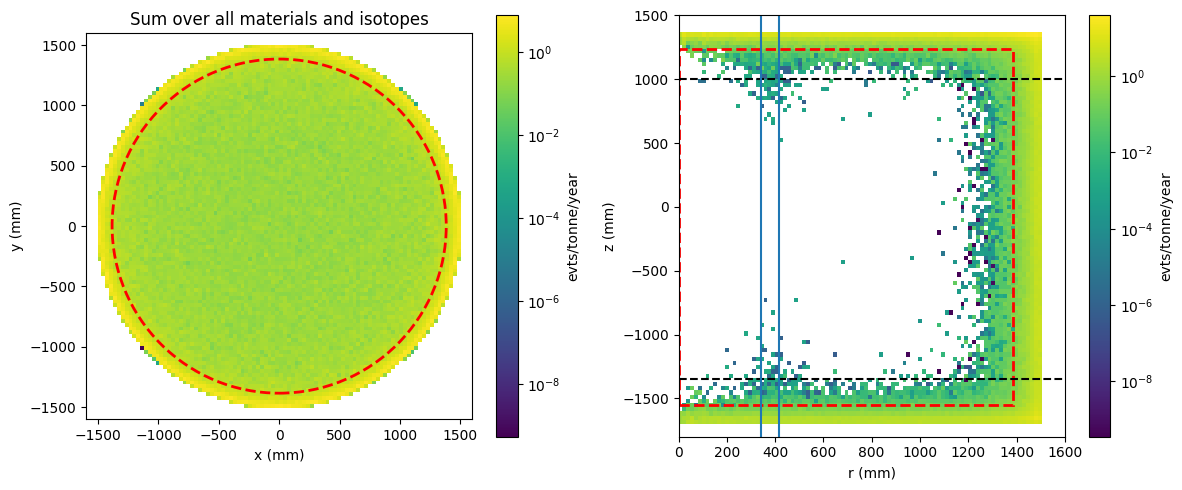

In [99]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
tag = "_ss_energy"

h_xy_total = estimates['Copper']['Th232']["h_xy_ss_energy"].copy()*0.0
h_rz_total = estimates['Copper']['Th232']["h_rz_ss_energy"].copy()*0.0
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        h_xy_total += iso_data["h_xy"+tag]/iso_data['simulated_exposure_years'] # per year
        h_rz_total += iso_data["h_rz"+tag]/iso_data['simulated_exposure_years'] # per year

scale = 2
h_xy_total = h_xy_total[::bh.rebin(scale), ::bh.rebin(scale)]
h_rz_total = h_rz_total[::bh.rebin(scale), ::bh.rebin(scale)]

h_xy_total /= v_xy[::bh.rebin(scale), ::bh.rebin(scale)] # per year per tonne
h_rz_total /= v_rz[::bh.rebin(scale), ::bh.rebin(scale)] # per year per tonne

pcm1 = ax1.pcolormesh(*h_xy_total.axes.edges.T, h_xy_total.values().T, norm=matplotlib.colors.LogNorm())
ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

ax1.set_title(f"Sum over all materials and isotopes")
ax1.set_xlabel("x (mm)")
ax1.set_ylabel("y (mm)")
ax1.set_aspect('equal', adjustable='box')

pcm2 = ax2.pcolormesh(*h_rz_total.axes.edges.T, h_rz_total.values().T, norm=matplotlib.colors.LogNorm())
ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

ax2.axhline(-1350, color='black', linestyle='--', label='TPC Bottom')
ax2.axhline(1000, color='black', linestyle='--', label='TPC Top')

ax2.axvline(340)
ax2.axvline(415)

ax2.set_xlabel("r (mm)")
ax2.set_ylabel("z (mm)")

plt.colorbar(pcm1, label="evts/tonne/year")
plt.colorbar(pcm2, label="evts/tonne/year")
fig.tight_layout()
plt.show()

In [100]:
# print where 1 event per tonne per year is reached
for hist in [h_rz_nominal, h_rz_total]:
    h_r_slice = hist[:bh.loc(G4_TPC["radius"]), bh.loc(-1350):bh.loc(1000):bh.sum]
    energy_range = 50-4

    counts = h_r_slice.view()
    cumulative_counts = np.cumsum(counts)/energy_range

    r_edges = h_r_slice.axes[0].edges
    r_centers = h_r_slice.axes[0].centers

    idx = np.searchsorted(cumulative_counts, 1.0)
    if idx < len(r_centers):
        print(f"1 evt/tonne/year/keV reached at r = {r_centers[idx]:.2f} mm")
    else:
        print("1 evt/tonne/year/keV not reached within TPC radius")

1 evt/tonne/year/keV reached at r = 1384.00 mm
1 evt/tonne/year/keV reached at r = 1384.00 mm


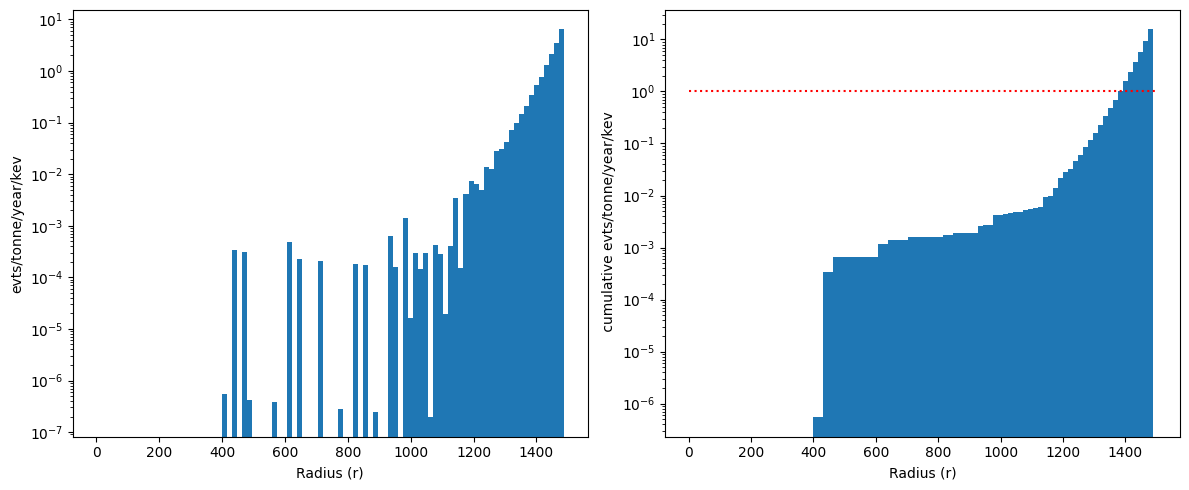

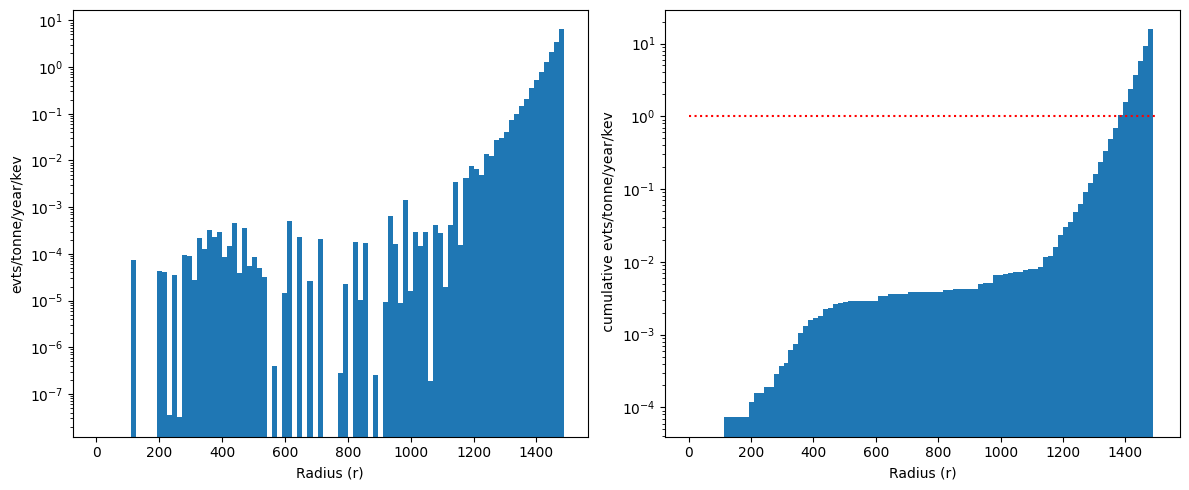

In [101]:
for hist in [h_rz_nominal, h_rz_total]:

    fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

    h_r_slice = hist[:bh.loc(G4_TPC["radius"]), bh.loc(-1350):bh.loc(1000):bh.sum]
    energy_range = 50-4

    main_axis = h_r_slice.axes[0]
    ax1.bar(main_axis.centers, h_r_slice.view()/energy_range, width=main_axis.widths)

    ax1.set_xlabel("Radius (r)")
    ax1.set_ylabel("evts/tonne/year/kev")
    ax1.set_yscale('log')

    # Cumulative Plots
    counts = h_r_slice.view()
    cumulative_counts = np.cumsum(counts)

    edges = h_r_slice.axes[0].edges
    ax2.stairs(cumulative_counts/energy_range, edges, fill=True)
    ax2.set_yscale('log')
    ax2.set_xlabel("Radius (r)")
    ax2.set_ylabel(" cumulative evts/tonne/year/kev")

    ax2.hlines(1, xmin=0, xmax=1500, linestyle =":", color='red')

    fig.tight_layout()
plt.show()

In [102]:
h_r_slice = v_rz[:bh.loc(G4_TPC["radius"]), bh.loc(-1350):bh.loc(1000):bh.sum]
print(np.sum(h_r_slice.counts()))

47.147099257830796


In [86]:
h_rz_nosaph = h_rz_total.copy()
r_start = h_rz_nosaph.axes[0].index(340.0)
r_end   = h_rz_nosaph.axes[0].index(450.0)
h_rz_nosaph.view(flow=True)[r_start:r_end, :] = 0
h_r_slice = h_rz_nosaph[:bh.loc(G4_TPC["radius"]), bh.loc(-1350):bh.loc(1000):bh.sum]

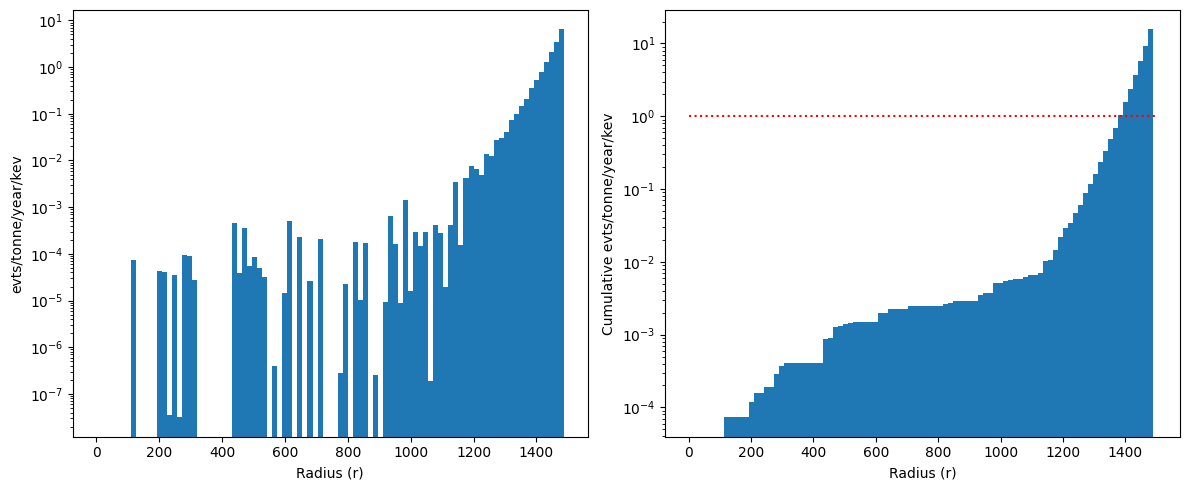

In [87]:
fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))

main_axis = h_r_slice.axes[0]
ax1.bar(main_axis.centers, h_r_slice.view()/energy_range, width=main_axis.widths)
ax1.set_xlabel("Radius (r)")
ax1.set_ylabel("evts/tonne/year/kev")
ax1.set_yscale('log')

# Cumulative Plots
counts = h_r_slice.view()
cumulative_counts = np.cumsum(counts)

edges = h_r_slice.axes[0].edges
ax2.stairs(cumulative_counts/energy_range, edges, fill=True)
ax2.set_yscale('log')
ax2.set_xlabel("Radius (r)")
ax2.set_ylabel("Cumulative evts/tonne/year/kev")

ax2.hlines(1, xmin=0, xmax=1500, linestyle =":", color='red')

fig.tight_layout()
plt.show()

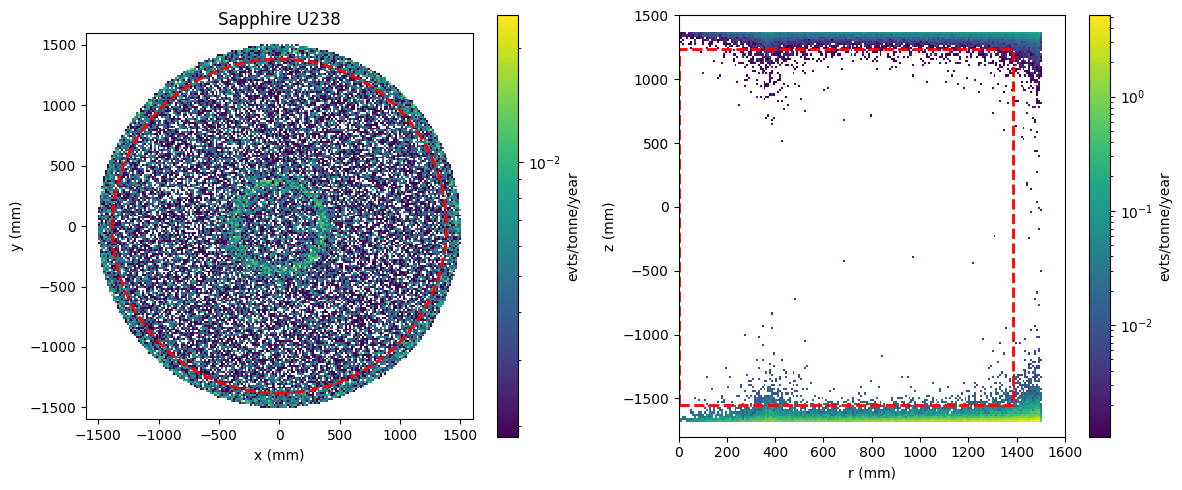

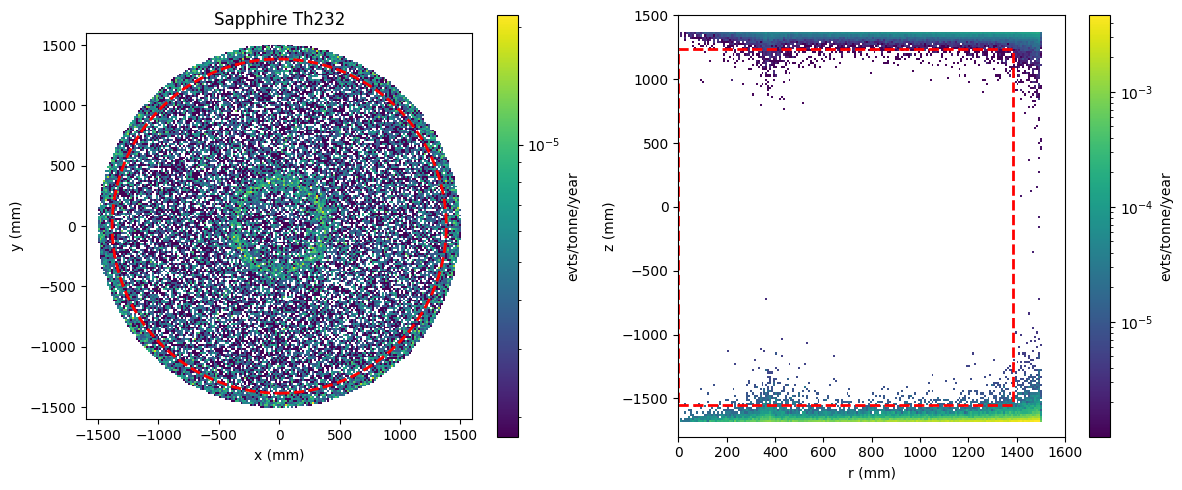

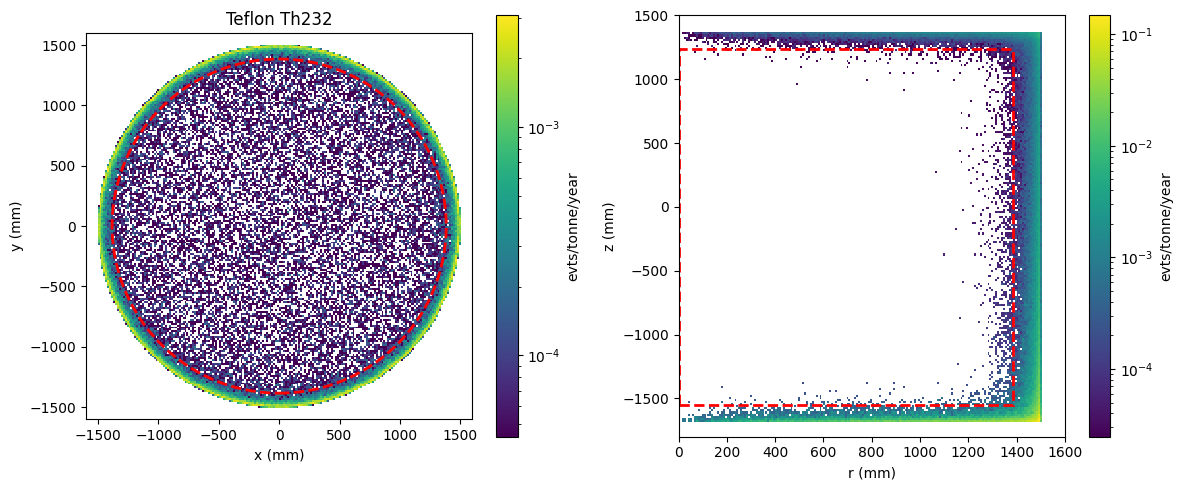

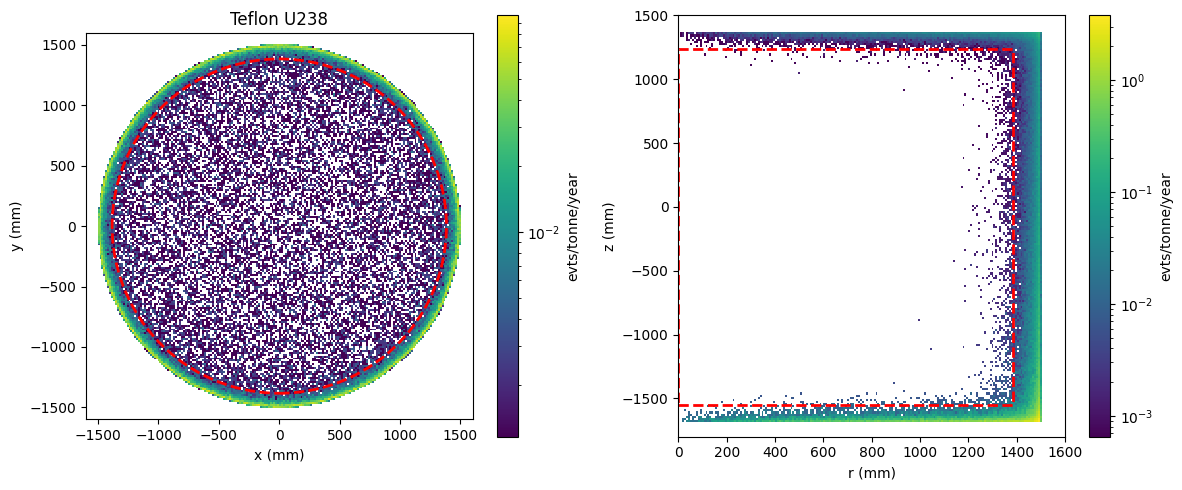

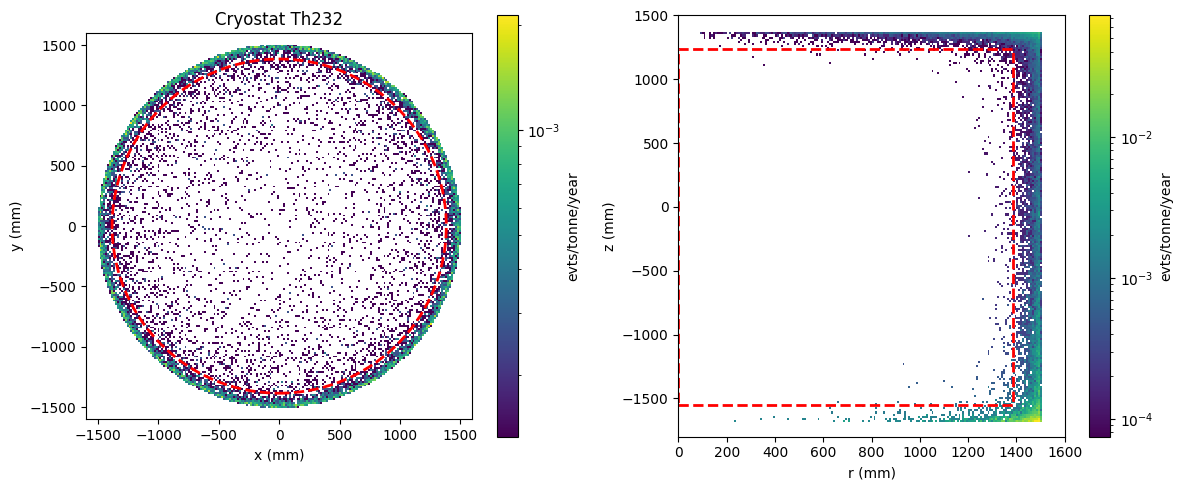

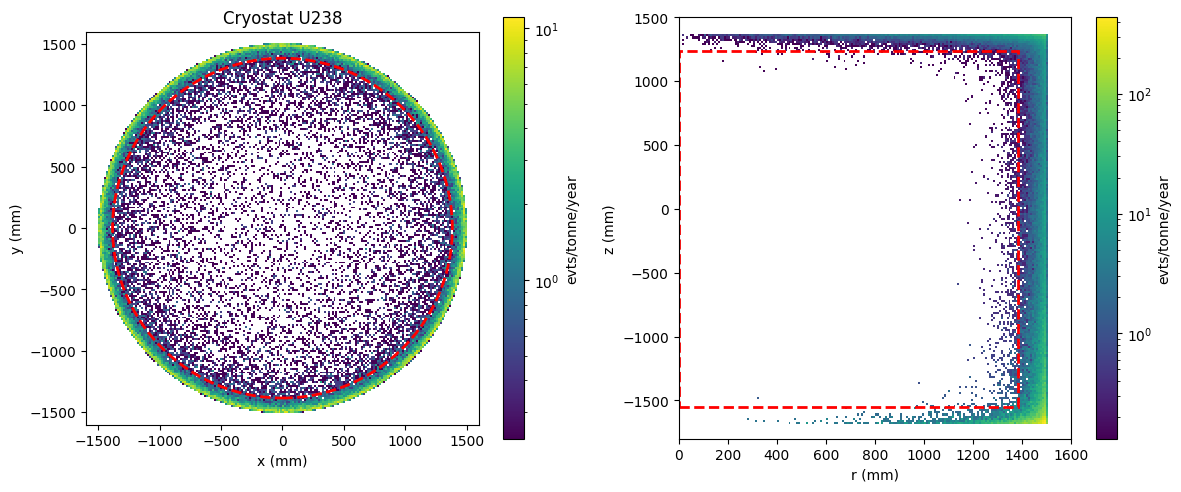

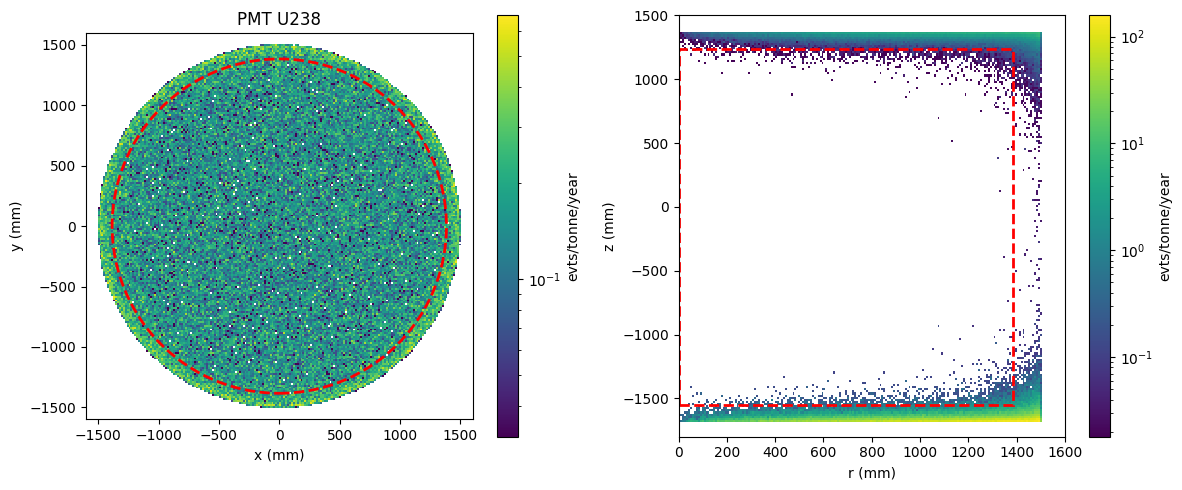

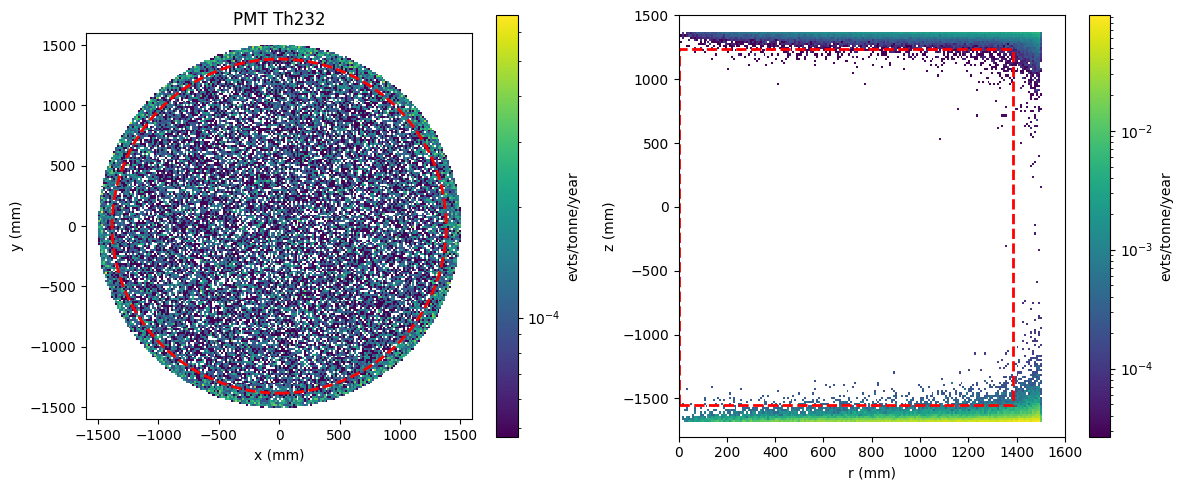

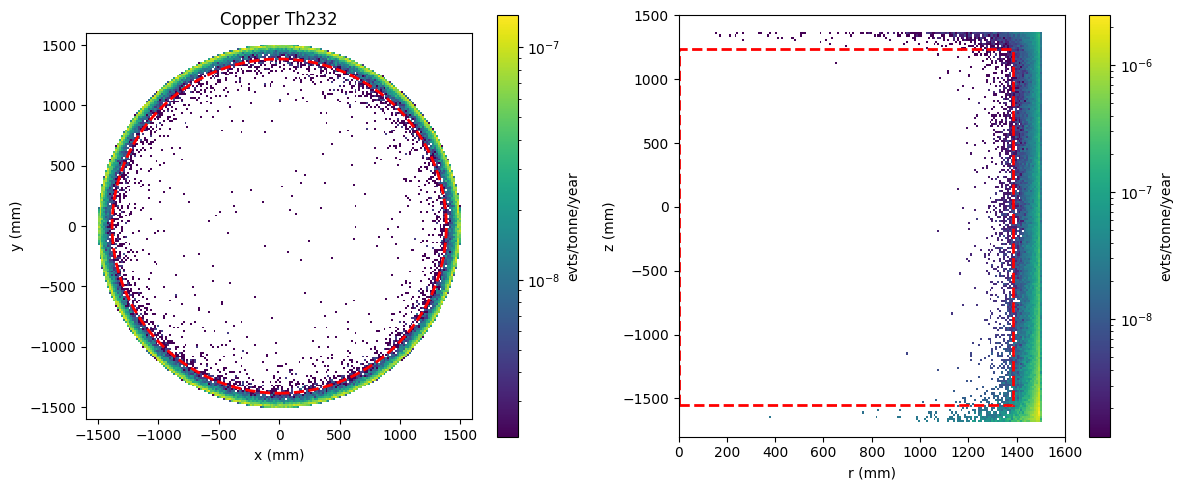

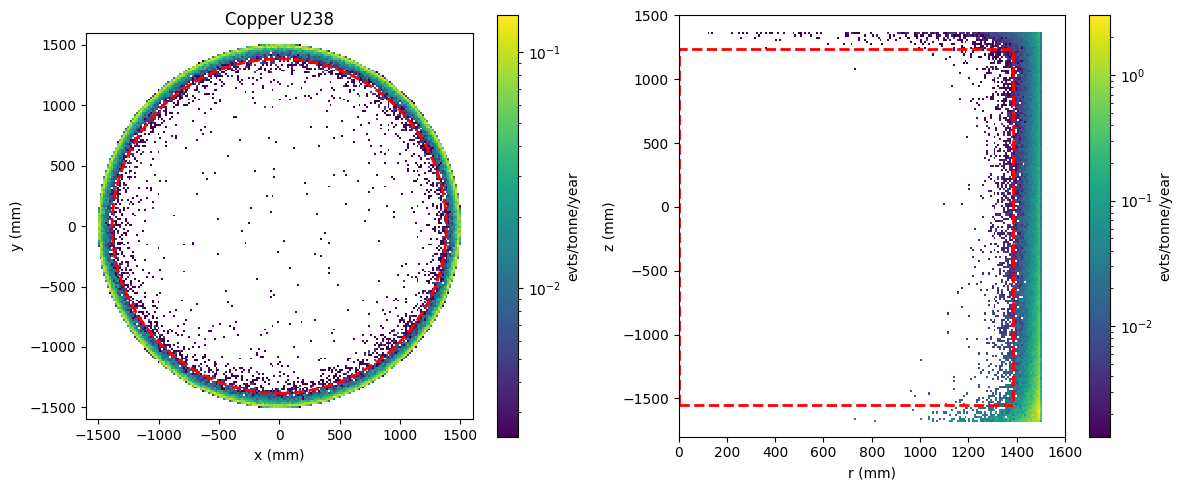

In [ ]:
for material, mat_data in estimates.items():
    for isotope, iso_data in mat_data.items():
        fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(12,5))
        tag = "_ss_energy"

        pcm1 = ax1.pcolormesh(*iso_data["h_xy"+tag].axes.edges.T, iso_data["h_xy"+tag].values().T/iso_data['simulated_exposure_years']/v_xy, norm=matplotlib.colors.LogNorm())
        ax1.add_patch(plt.Circle((0, 0), fv_radius, color='red', fill=False, linestyle='--', linewidth=2, label='Fiducial Volume'))

        ax1.set_title(f"{material} {isotope}")
        ax1.set_xlabel("x (mm)")
        ax1.set_ylabel("y (mm)")
        ax1.set_aspect('equal', adjustable='box')

        pcm2 = ax2.pcolormesh(*iso_data["h_rz"+tag].axes.edges.T, iso_data["h_rz"+tag].values().T/iso_data['simulated_exposure_years']/v_rz, norm=matplotlib.colors.LogNorm())
        ax2.add_patch(plt.Rectangle((-0, fv_z[0]), fv_radius, fv_z[1]-fv_z[0], color='red', fill=False, linestyle='--', linewidth=2))

        ax2.set_xlabel("r (mm)")
        ax2.set_ylabel("z (mm)")

        plt.colorbar(pcm1, label="evts/tonne/year")
        plt.colorbar(pcm2, label="evts/tonne/year")
        fig.tight_layout()
        plt.show()